# Notebook guide: VTA DA Neuron model

This notebook implements a 3-compartment HH-style dopamine neuron model for `Saline` and `Cocaine` groups, then calibrates each group to match target capacitance (`Cm`), h-current conductance at `-130 mV` (`Gh`), and input resistance (`Rin`).

## Cell map
- Cell 1: all model definitions, calibration functions, protocols, plotting helpers, and the main wrapper `run_and_plot_2012_2017_replication(...)`.
- Cell 2: a ready-to-run example using the 2012-like pharmacology setup and the `Eh = -39 mV` configuration.
- Cell 3: the same wrapper inside an `if __name__ == "__main__":` block so the notebook can also be exported and reused more like a script.

## Recommended workflow
1. Run Cell 1 once to define the full model.
2. Edit Cell 2 if you want to change the experimental condition, clamp settings, target capacitances, or plotting behavior.
3. Re-run Cell 2 to regenerate the overlays and summary metrics.

## Most important parameters to modify
- `Eh_run`: switch between a 2012-like `-39 mV` run and a 2021-like `-53 mV` run.
- `cm_sal`, `cm_coc`: total capacitance targets used to size the saline and cocaine models.
- `TAU_H_SCALE`: scales h-current activation kinetics without changing steady-state activation.
- `H_VHALF_MV`, `H_SLOPE_MV`: shift or broaden the steady-state h-activation curve.
- `ih_traces_*` vs `ih_metrics_*`: choose whether the displayed traces and the measured Gh/Boltzmann overlays are computed under the same clamp condition.
- `pharm`: use `"none"`, `"2012_like"`, or a custom dictionary from `get_pharm_profile(...)`.


## Commentary on `finalized model 9 kinetics.ipynb`

This notebook is the main working baseline for the VTA DA neuron project. Its purpose is to use a 3-compartment Hodgkin-Huxley style model to reproduce the experimental saline vs cocaine differences reported in the 2012/2017-style datasets, with special emphasis on the hyperpolarization-activated current `Ih`.

### Main purpose

The notebook was designed to answer the following question:

Can a physiologically constrained conductance-based DA neuron model reproduce the observed differences in `Gh`, `Ih` amplitude, activation kinetics, input resistance, temporal summation, and evoked excitability between saline and cocaine groups?

To do that, the notebook does not simply simulate one fixed neuron. Instead, it calibrates group-specific versions of the model so that each group matches experimental target values.

### General approach

The strategy used in this notebook is:

1. Start from a biologically motivated 3-compartment DA neuron model.
2. Include the relevant intrinsic conductances across soma, proximal, and dendritic compartments.
3. Scale the model to match experimentally measured total membrane capacitance.
4. Adjust the `H` conductance so the model reproduces the target `Gh` at `-130 mV`.
5. Adjust leak so the model reproduces the target `Rin`.
6. Run a series of voltage-clamp and current-clamp protocols that parallel the experiments.
7. Compare saline and cocaine outputs side by side.

This means the notebook is both a **model definition notebook** and a **replication/phenotyping notebook**.

### What the model includes

The model is a 3-compartment conductance-based neuron with:

- sodium current
- delayed rectifier potassium current
- SK current
- A-type current
- M-like current
- GIRK current
- CaL current
- h-current
- ERG current
- leak current

Each compartment has its own conductance values, while total size can be scaled to reproduce experimentally observed capacitance.

It introduced tuning knobs such as:

- `TAU_H_SCALE`: scales `Ih` activation kinetics
- `H_VHALF_MV`: shifts the steady-state activation curve
- `H_SLOPE_MV`: changes the steepness of the activation curve
- `COUP_SCALE`: slightly adjusts inter-compartment coupling

These parameters were added so the model could better match both physiological expectations and the digitized target values, rather than only fitting one metric at a time.

### Experimental logic used in the notebook

The notebook tries to mirror the logic of the experimental analysis by measuring model outputs through protocol-based readouts rather than just inspecting raw internal variables.

The main protocols include:

- `Ih` voltage-clamp family
- extraction of instantaneous (`Iins`) and steady-state (`Iss`) currents
- computation of `ΔI`, `Gh(V)`, and normalized `Gh`
- Boltzmann fits for activation curves
- tail-current analysis and `Eh` estimation
- membrane tau estimation
- alpha-EPSP and temporal summation protocols
- evoked spike responses

### Saline vs cocaine handling

A major feature of the notebook is that saline and cocaine are treated as separate calibrated groups.

For each group, the notebook:

- matches the requested total capacitance (`Cm`)
- calibrates `H` scaling to hit the target `Gh`
- tunes leak to match the target `Rin`

This allows the notebook to ask whether the same model structure, with group-specific calibrated parameters, can account for the observed physiological differences.

### Clamp and pharmacology strategy

Another important feature of this notebook is that it distinguishes between:

- the conditions used to display traces
- the conditions used to compute metrics
- idealized stiff voltage clamp vs finite-`Ra` voltage clamp
- protocol-specific pharmacology

This matters because measured `Ih` amplitudes and fitted activation properties depend not only on the underlying conductance, but also on how the protocol is implemented.

So the notebook does not assume that all metrics should be measured under one single universal clamp condition.

It combines:

- the stabilized 3-compartment model
- explicit `Ih` kinetic and steady-state controls
- group-specific calibration
- protocol-aware readouts
- saline vs cocaine comparison plots and summaries

For that reason, `finalized model 9 kinetics.ipynb` serves as the main reference point for later fitting and refinement work.


[Saline]  size_scale=0.772  => Cm≈61.8 pF ; base_params={'H': 0.9601303142594332, 'LEAK': 0.383673401284853}
[Cocaine] size_scale=0.516  => Cm≈41.3 pF ; base_params={'H': 0.5953460486143834, 'LEAK': 0.5338894734670231}


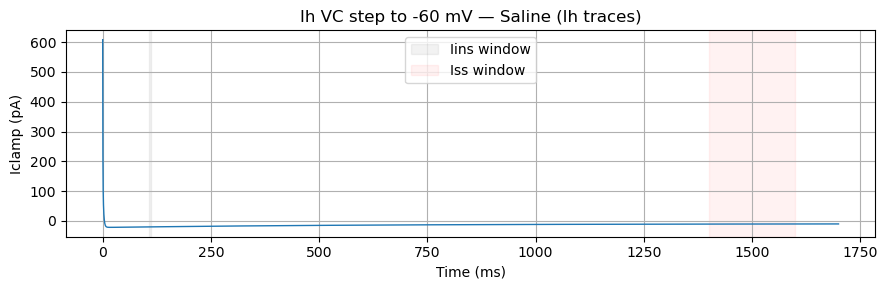

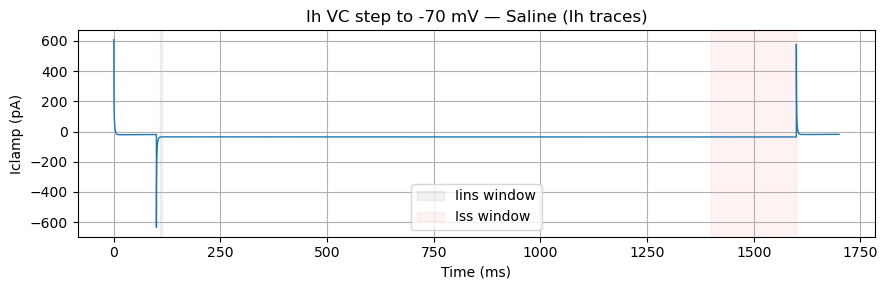

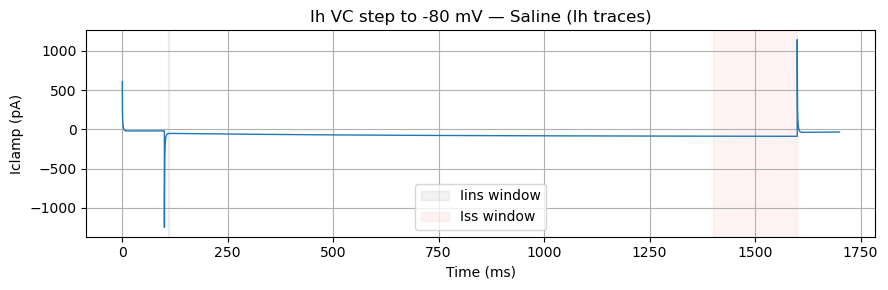

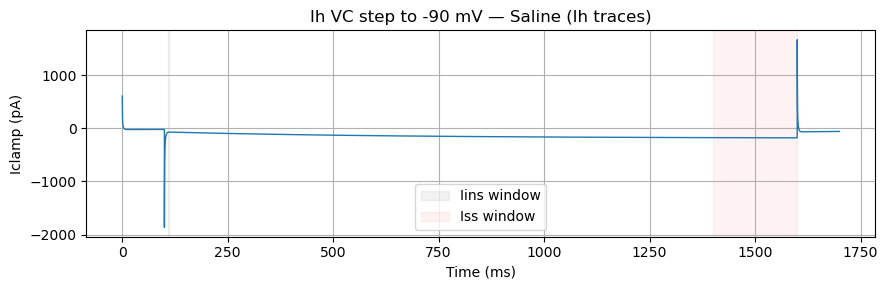

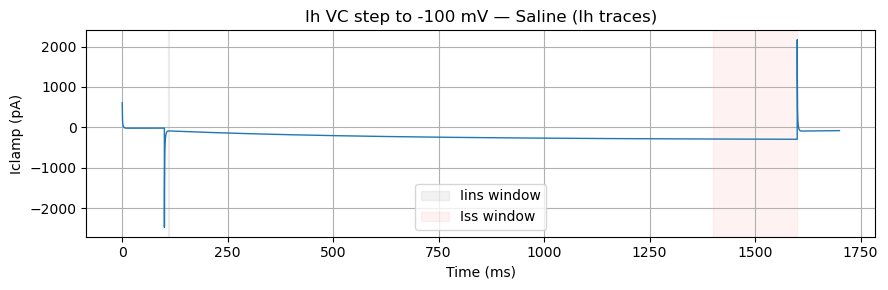

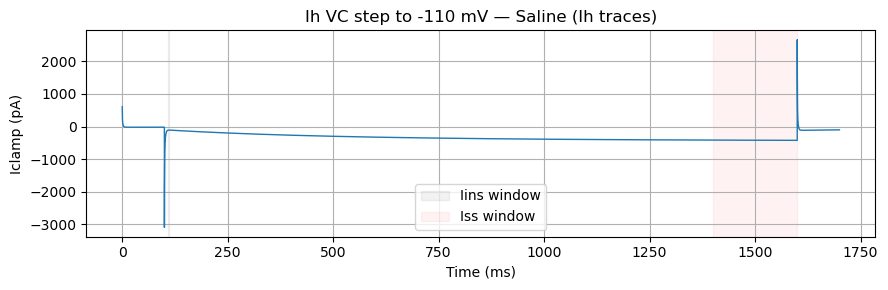

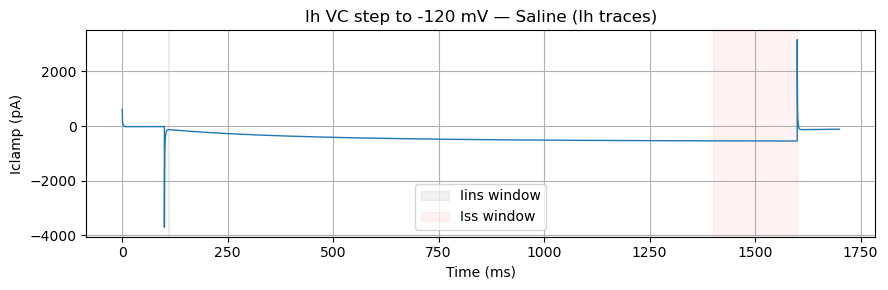

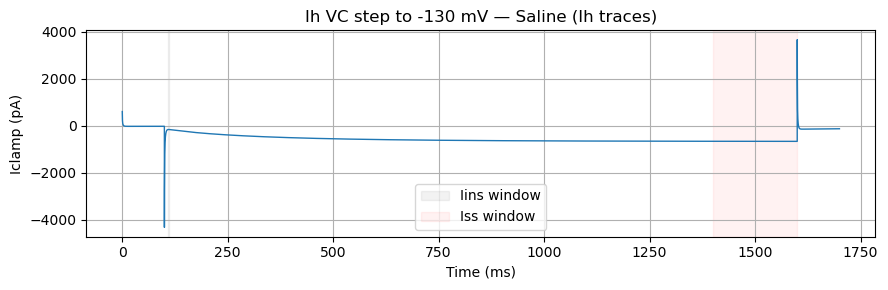

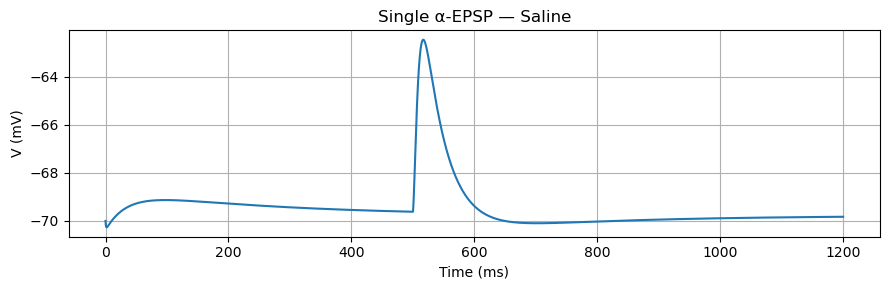

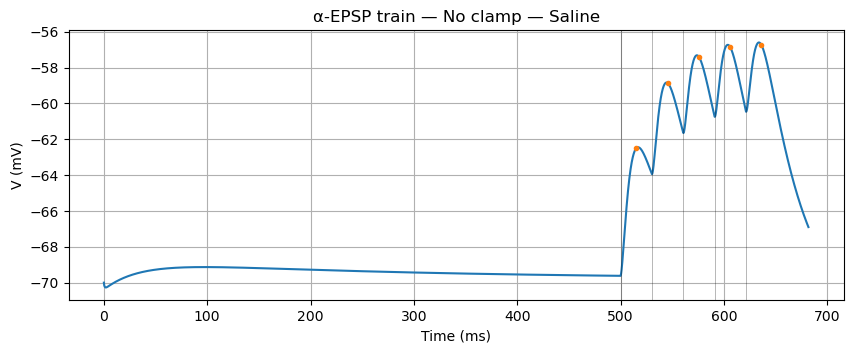

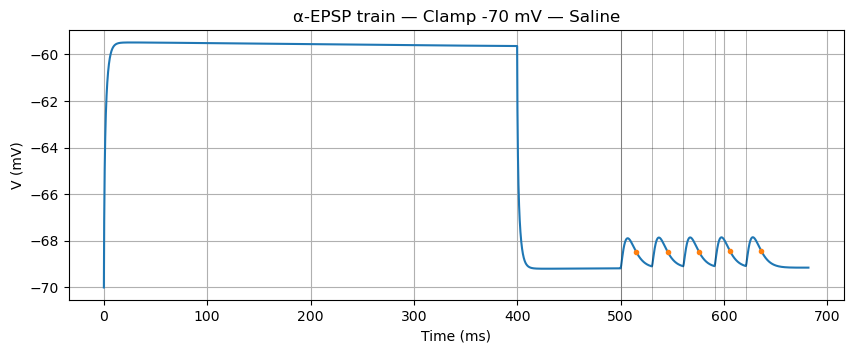

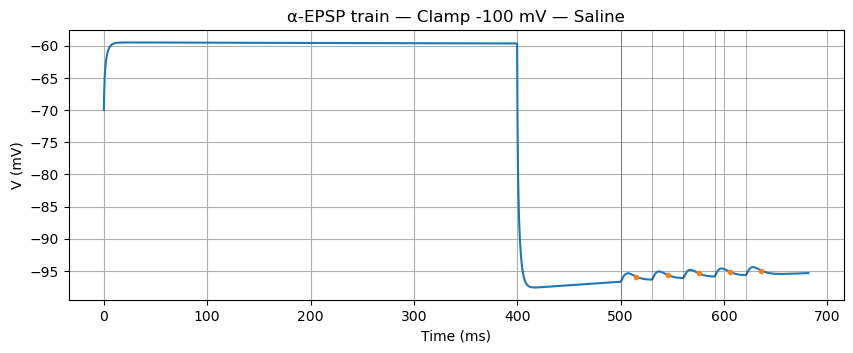

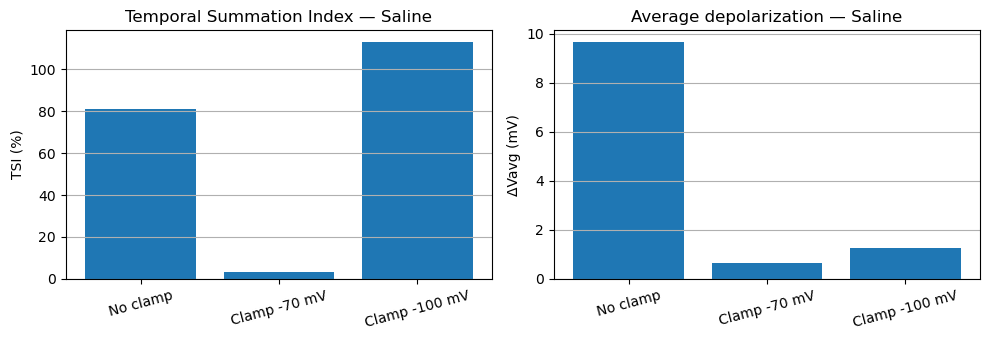

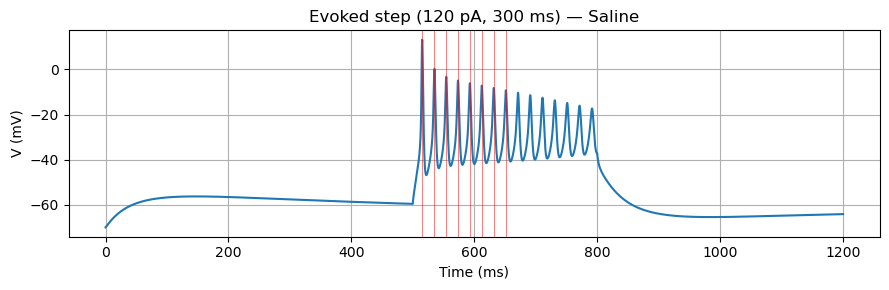

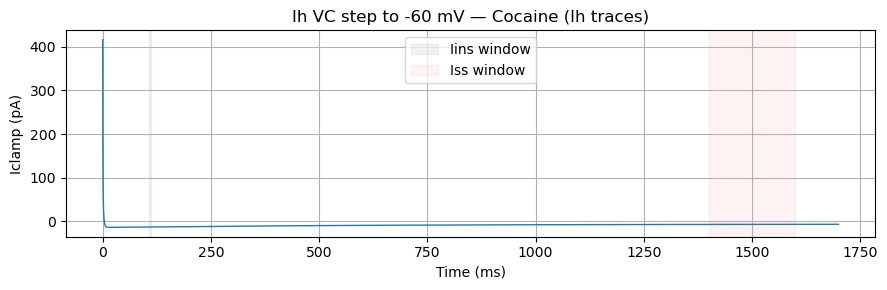

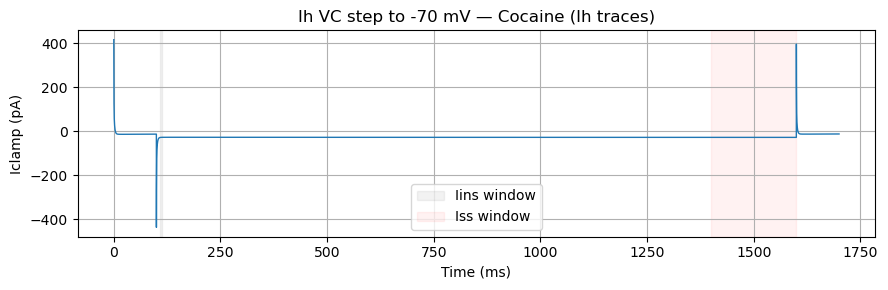

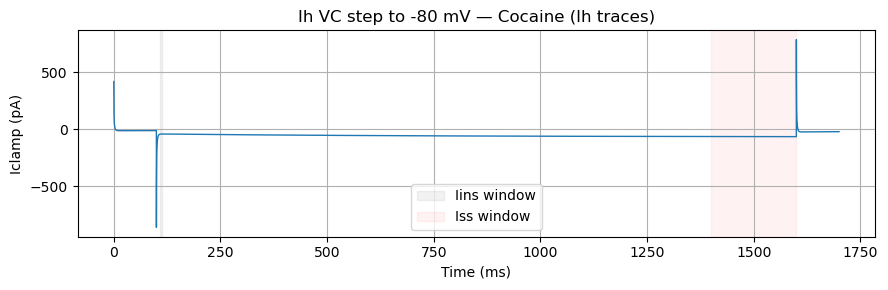

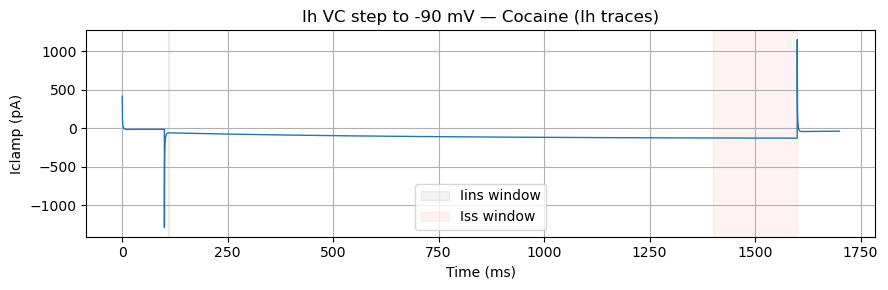

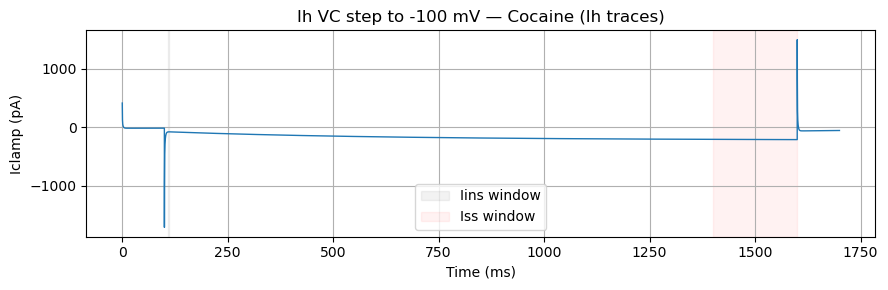

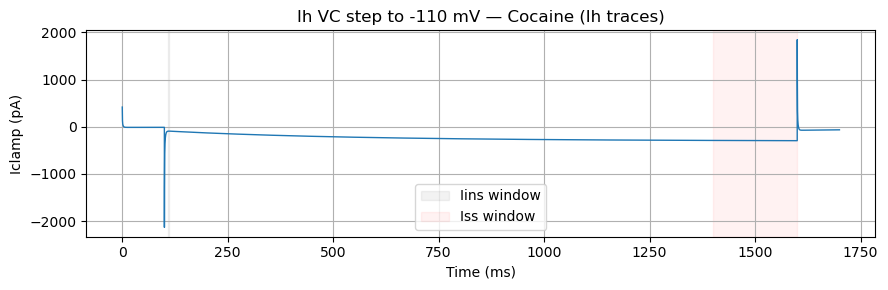

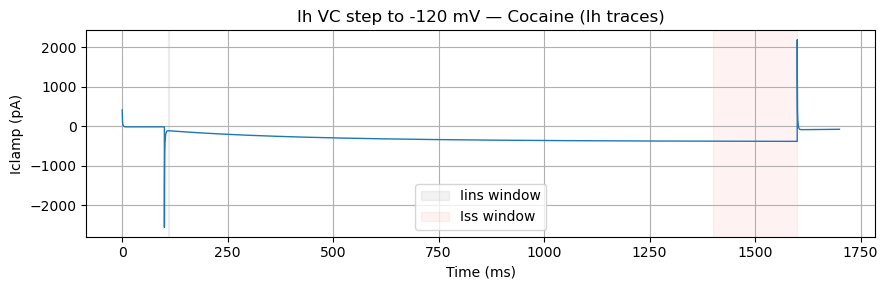

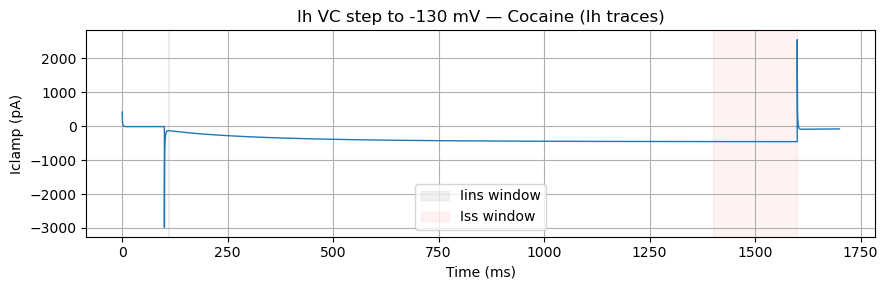

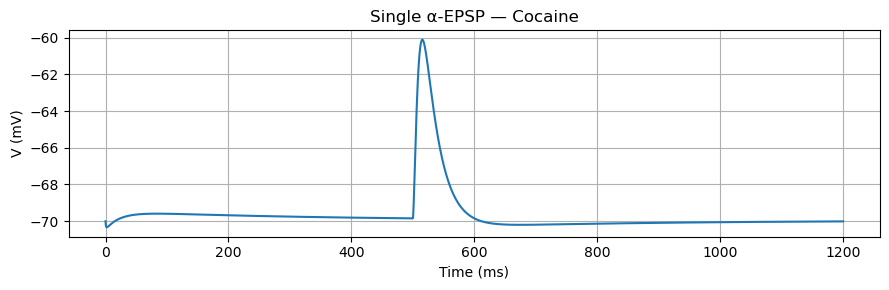

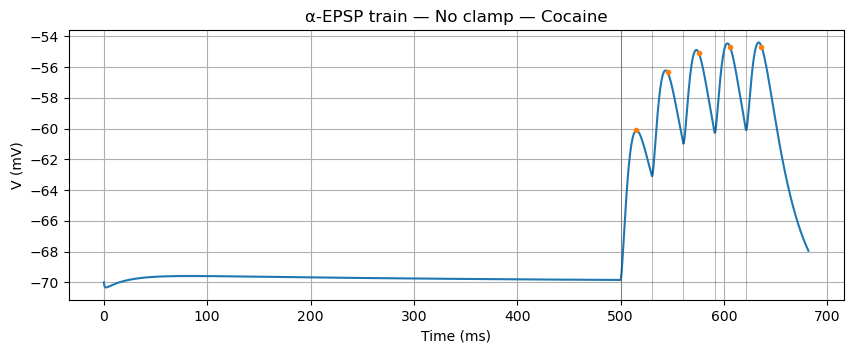

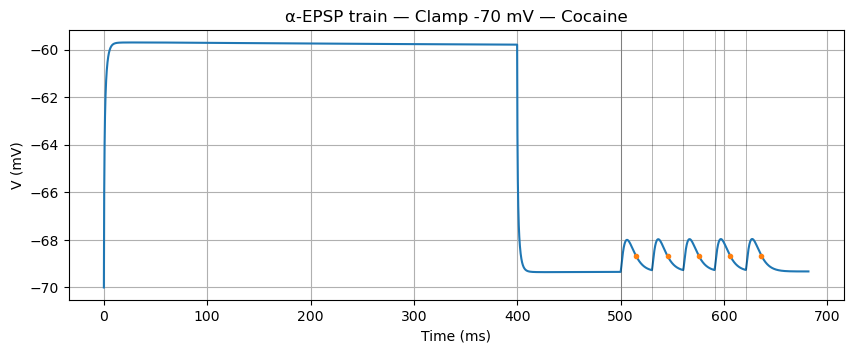

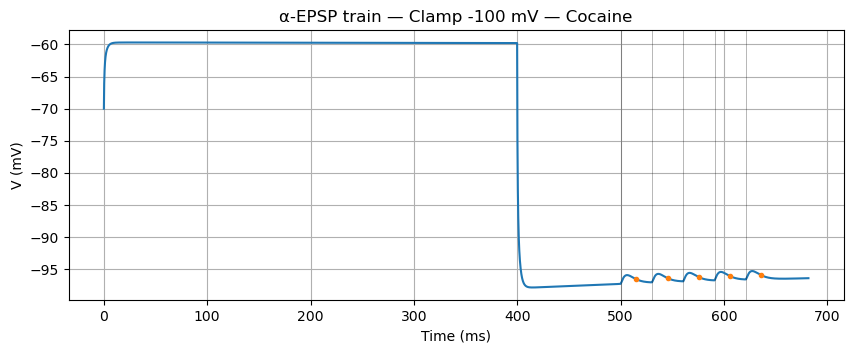

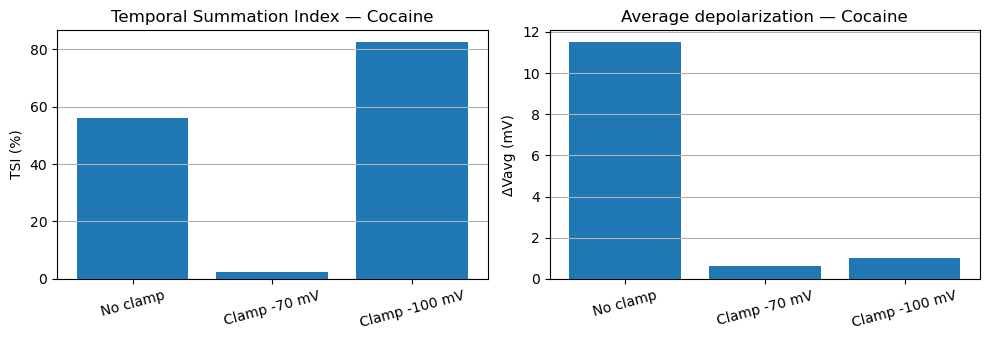

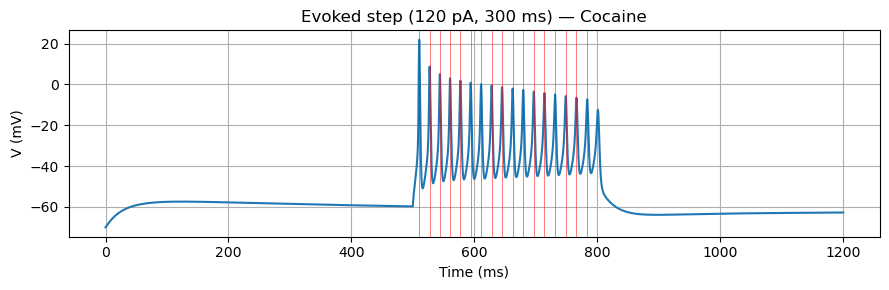

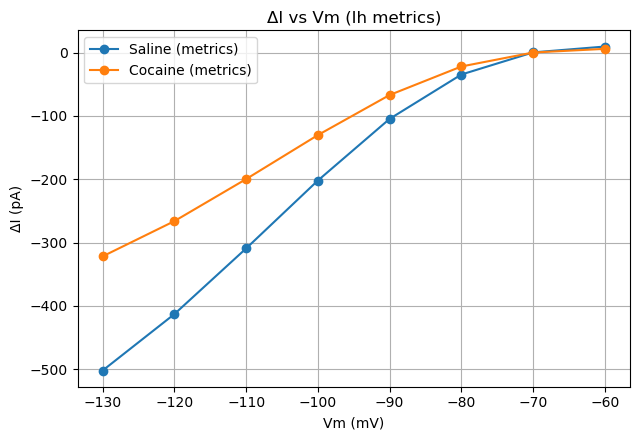

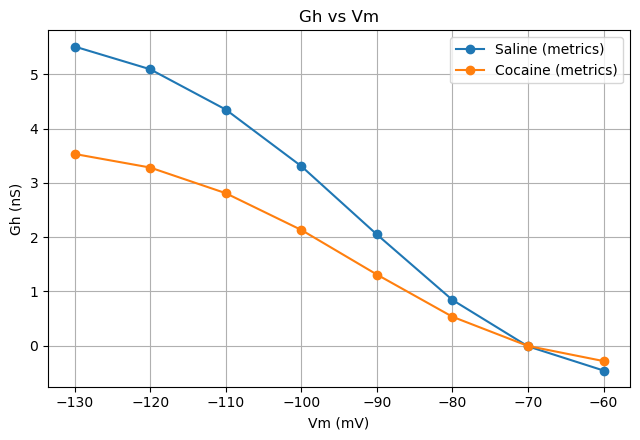

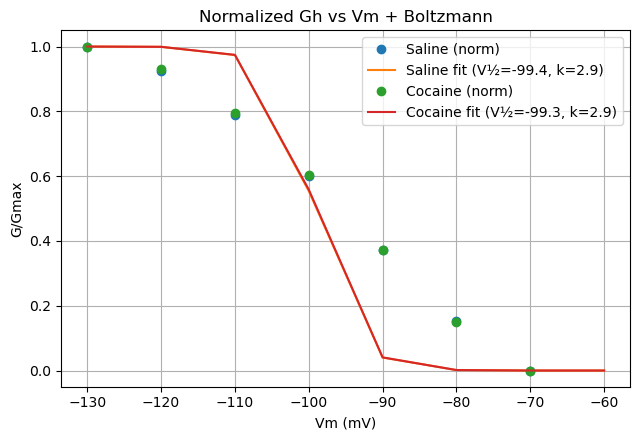

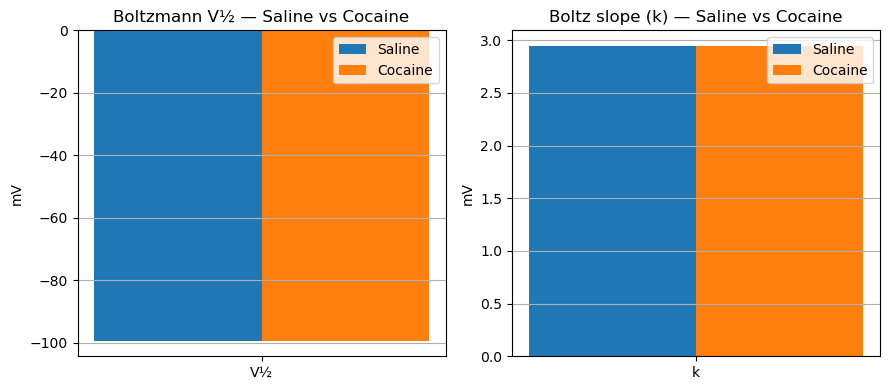

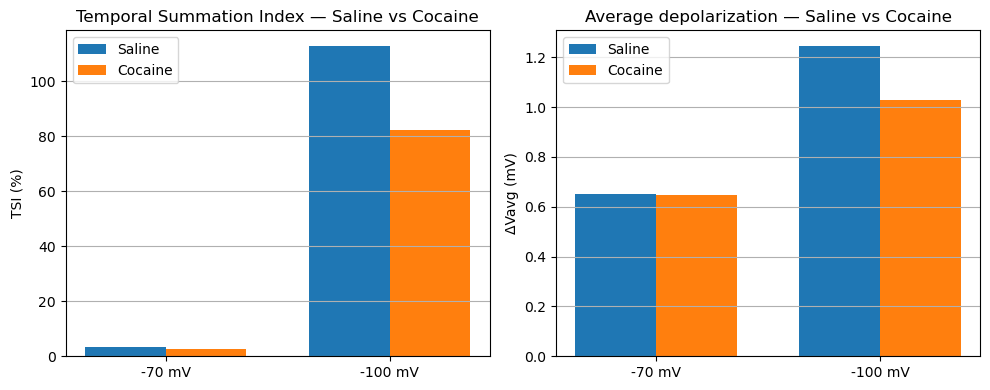

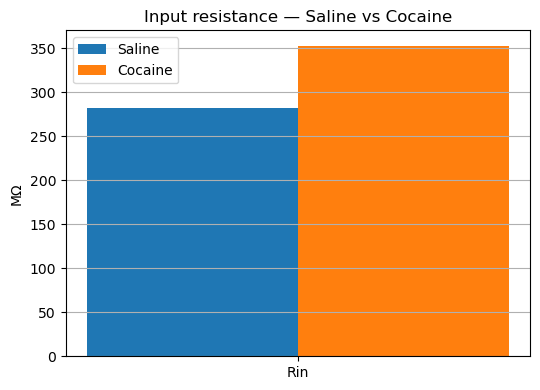

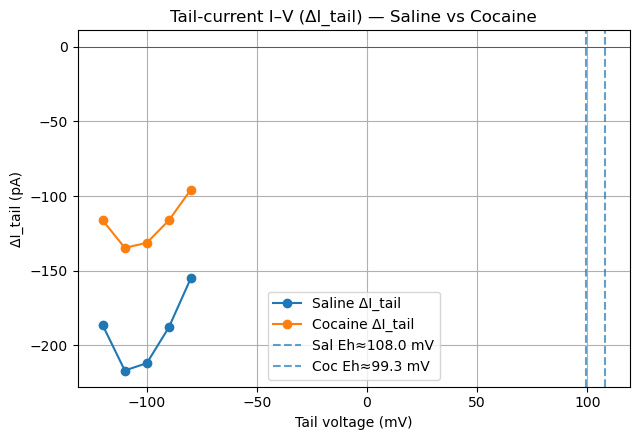

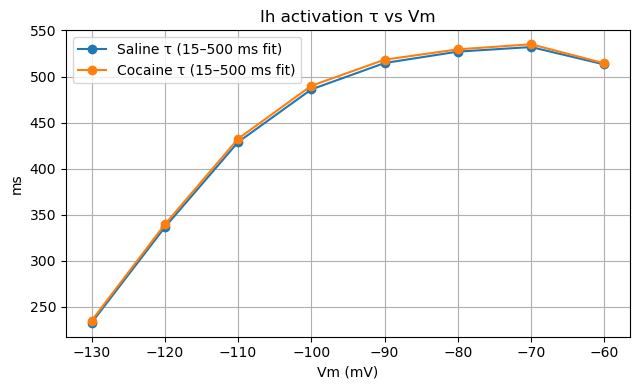


=== Summary (key numbers) ===
Ih ΔI@-130 mV   Saline: -501.9 pA | Cocaine: -321.6 pA
Gh@-130  Saline:  5.515 nS (target 5.3) | Cocaine:  3.534 nS (target 3.1)
Ghmax     Saline:  5.515 nS               | Cocaine:  3.534 nS
Rin       Saline:  281.6 MΩ (target 280)  | Cocaine:  352.5 MΩ (target 350)
Boltzmann V½      Saline: -99.36 mV | Cocaine: -99.31 mV
Boltzmann k       Saline: 2.95 mV | Cocaine: 2.94 mV
τ_act@-130 mV     Saline: 232.7 ms | Cocaine: 234.9 ms


In [2]:
# ============================
# 3-compartment model + internal checks (Saline/Cocaine)
# — PHARM + TAIL FIXES + TAU + selectable clamp modes + corrected TSI/ΔVavg
# ============================

# Reading map for this cell:
# 1) Global constants and gating equations.
# 2) Group targets and pharmacology presets.
# 3) `simulate(...)`: the low-level forward model.
# 4) Calibration helpers: match Cm, Gh@-130 mV, and Rin.
# 5) Protocol helpers: Ih families, alpha-EPSP, train summation, evoked spikes.
# 6) `run_all_protocols_inline(...)`: run one group through the full protocol set.
# 7) `run_and_plot_2012_2017_replication(...)`: top-level entry point for most use cases.
# 8) Debug/report helpers and an example call.

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ---- Constants (units: V mV, g nS, C pF, I pA, t ms) ----
E_NA = 40.0
E_K  = -78.0
E_CA = 70.0
E_H  = -53.0  # default to 2021 paper; use Eh_mV=-39.0 for 2012-like runs

# --- Optional kinetic & steady-state tuning knobs ---
# For ~200 ms activation at -130 mV, try TAU_H_SCALE ≈ 2.0–2.5 (e.g., 2.2)
TAU_H_SCALE = 2.2   # <1.0 speeds Ih; >1.0 slows Ih (affects τ only, not steady state), 2.2 roughly replicates Arencibia's 2012 results
H_VHALF_MV  = -90.0 # keep original so steady state is unchanged unless you want to adjust k
H_SLOPE_MV  = 10   # increase toward 9–12 mV ONLY if you need a bigger fitted k (shallower G–V)
COUP_SCALE  = 1.0   # set to 0.9–0.95 ONLY if you still need a small Iins boost

# Leak reversals (per compartment; paper values)
E_LEAK_S = -58.0; E_LEAK_P = -58.0; E_LEAK_D = -58.0

# Capacitances (baseline; scale by size_scale)
C_S = 20.0; C_P = 30.0; C_D = 30.0

# Electrical couplings (baseline; scale by size_scale)
G_SP = 234.0
G_PD = 22.8

# Maximal conductances (baseline)
G_NA_S = 450.0; G_NA_P = 450.0; G_NA_D = 450.0
G_K_S  = 225.0; G_K_P  = 175.0; G_K_D  = 175.0
G_SK_S = 0.25;  G_SK_P = 0.25;  G_SK_D = 0.30
K_SK   = 1.9e-4  # mM
G_A_S  = 3.0;    G_A_P  = 4.0;   G_A_D  = 4.0
G_MU_S = 1.5;    G_MU_P = 1.8;   G_MU_D = 2.1
G_GIRK_S = 0.012; G_GIRK_P = 0.0144; G_GIRK_D = 0.0168
G_CAL_S = 0.14875; G_CAL_P = 0.2125; G_CAL_D = 0.2975
G_H_S   = 2.5;     G_H_P   = 3.0;     G_H_D   = 3.5
G_ERG_S = 0.30;    G_ERG_P = 0.36;    G_ERG_D = 0.42
G_LEAK_S = 0.35;   G_LEAK_P = 0.65;   G_LEAK_D = 0.65

# Calcium handling
FARADAY = 96520.0
fCa = 0.001
vol_fL = 0.0117
beta_Ca = 0.05
Ca_min = 1.0e-5

# ---- helpers ----
def _safe_div(num, denom, eps=1e-9):
    """Sign-preserving tiny-denominator protection."""
    if abs(denom) < eps:
        denom = np.sign(denom) * eps if denom != 0 else eps
    return num / denom

def clip01(x): return np.minimum(1.0, np.maximum(0.0, x))

def _nearest_at(x, xp, fp):
    xp = np.asarray(xp); fp = np.asarray(fp)
    i = int(np.nanargmin(np.abs(xp - x)))
    return float(fp[i])

# ---- Gating kinetics ----
def alpha_m(V):  return (0.1*V + 2.5) / (1.0 - np.exp(-(0.1*V + 2.5) + 1e-12))
def beta_m(V):   return 4.0*np.exp(-(V + 50.0)/18.0)
def alpha_p(V):  return 0.07*np.exp(-(V + 40.0)/20.0)
def beta_p(V):   return 1.0/(1.0 + np.exp(-(0.1*V + 1.4)))
def hss_inf(V):  return 1.0/(1.0 + np.exp((V + 45.0)))
def tau_hss(V):  return 20.0 + 580.0/(1.0 + np.exp(V))
def alpha_n(V):  return 0.01*(V + 34.0) / (1.0 - np.exp(-0.2*(V + 34.0) + 1e-12))
def beta_n(V):   return 0.125*np.exp(-(V + 40.0)/80.0)
def r_inf(V):    return 1.0/(1.0 + np.exp((V + 63.0)/4.0))
def q_inf(V):    return 1.0/(1.0 + np.exp(-(V + 43.0)/24.0))
def alpha_mu(V): return 0.02/(1.0 + np.exp(-(V + 20.0)/5.0))
def beta_mu(V):  return 0.01*np.exp(-(V + 43.0)/18.0)
def l_inf(V):    return 1.0/(1.0 + np.exp(-(V + 42.0)/12.0))
def tau_l(V):    return 5.0*np.exp(-((V + 70.0)**2)/625.0) + 0.25
def h_inf_h(V):  return 1.0/(1.0 + np.exp((V - H_VHALF_MV)/H_SLOPE_MV))
def tau_h_h(V):  return 425.0*np.exp(0.075*(V + 112.0)) / (1.0 + np.exp(0.083*(V + 112.0)))
def alpha_o(V):  return 0.0036*np.exp(0.0759*V)
def beta_o(V):   return 1.2523e-5*np.exp(-0.0671*V)
def alpha_i(V):  return 92.11*np.exp(0.1189*V)
def beta_i(V):   return 12.6*np.exp(0.0733*V)
def girk_factor(V):  return 1.0/(1.0 + np.exp((V + 45.0)/20.0))

# ---- State & init ----
@dataclass
class State:
    VS: float; VP: float; VD: float
    mS: float; pS: float; hssS: float
    mP: float; pP: float; hssP: float
    mD: float; pD: float; hssD: float
    nS: float; nP: float; nD: float
    rS: float; qS: float; rP: float; qP: float; rD: float; qD: float
    uS: float; uP: float; uD: float
    lS: float; lP: float; lD: float
    hS: float; hP: float; hD: float
    oS: float; iS: float; oP: float; iP: float; oD: float; iD: float
    CaS: float; CaP: float; CaD: float

def _ss(a,b,V): return a(V)/(a(V)+b(V)+1e-12)

def initial_state(V0=-70.0):
    return State(
        VS=V0, VP=V0, VD=V0,
        mS=_ss(alpha_m,beta_m,V0), pS=_ss(alpha_p,beta_p,V0), hssS=hss_inf(V0),
        mP=_ss(alpha_m,beta_m,V0), pP=_ss(alpha_p,beta_p,V0), hssP=hss_inf(V0),
        mD=_ss(alpha_m,beta_m,V0), pD=_ss(alpha_p,beta_p,V0), hssD=hss_inf(V0),
        nS=_ss(alpha_n,beta_n,V0), nP=_ss(alpha_n,beta_n,V0), nD=_ss(alpha_n,beta_n,V0),
        rS=r_inf(V0), qS=q_inf(V0), rP=r_inf(V0), qP=q_inf(V0), rD=r_inf(V0), qD=q_inf(V0),
        uS=_ss(alpha_mu,beta_mu,V0), uP=_ss(alpha_mu,beta_mu,V0), uD=_ss(alpha_mu,beta_mu,V0),
        lS=l_inf(V0), lP=l_inf(V0), lD=l_inf(V0),
        hS=h_inf_h(V0), hP=h_inf_h(V0), hD=h_inf_h(V0),
        oS=0.0, iS=0.0, oP=0.0, iP=0.0, oD=0.0, iD=0.0,
        CaS=Ca_min, CaP=Ca_min, CaD=Ca_min
    )

# ---- Effective conductances (thread Eh_mV) ----
def effective_conductances(st, params, Eh_mV):
    G = {}
    for comp in ['S','P','D']:
        V = getattr(st, f'V{comp}')
        gna = params[f'G_NA_{comp}']; gk=params[f'G_K_{comp}']; gsk=params[f'G_SK_{comp}']
        ga=params[f'G_A_{comp}']; gmu=params[f'G_MU_{comp}']; ggirk=params[f'G_GIRK_{comp}']
        gcal=params[f'G_CAL_{comp}']; gh=params[f'G_H_{comp}']; gerg=params[f'G_ERG_{comp}']
        gleak=params[f'G_LEAK_{comp}']; E_leak=params[f'E_LEAK_{comp}']

        m=getattr(st,f'm{comp}'); p=getattr(st,f'p{comp}'); hss=getattr(st,f'hss{comp}')
        n=getattr(st,f'n{comp}'); r=getattr(st,f'r{comp}'); q=getattr(st,f'q{comp}')
        u=getattr(st,f'u{comp}'); l=getattr(st,f'l{comp}'); hh=getattr(st,f'h{comp}')
        o=getattr(st,f'o{comp}')

        f_girk = girk_factor(V)
        Ca = getattr(st, f'Ca{comp}')
        gsk_eff = gsk / (1.0 + (K_SK/max(Ca,1e-9))**4)

        g_eff_na = gna*(m**3)*p*hss
        g_eff_k  = gk*(n**4)
        g_eff_a  = ga*r*(q**3)
        g_eff_mu = gmu*u
        g_eff_girk = ggirk*f_girk
        g_eff_cal = gcal*l
        g_eff_h   = gh*hh
        g_eff_erg = gerg*o
        g_eff_leak= gleak

        Gtot = (g_eff_na + g_eff_k + gsk_eff + g_eff_a + g_eff_mu +
                g_eff_girk + g_eff_cal + g_eff_h + g_eff_erg + g_eff_leak)

        Eterm = (
            g_eff_na*E_NA +
            (g_eff_k + gsk_eff + g_eff_a + g_eff_mu + g_eff_girk + g_eff_erg)*E_K +
            g_eff_cal*E_CA + g_eff_h*Eh_mV + g_eff_leak*E_leak
        )
        G[comp] = {'Gtot': Gtot, 'Eterm': Eterm, 'gcal_eff': g_eff_cal, 'g_h_eff': g_eff_h}
    return G

# ---- Coupling scaling & groups ----
def _couplings_from_scale(size_scale: float):
    return (G_SP * COUP_SCALE) * size_scale, (G_PD * COUP_SCALE) * size_scale

@dataclass
class GroupTarget:
    name: str
    Cm_total_pF: float
    Gh_target_nS_at_minus130: float
    Rin_target_MOhm: float

SALINE  = GroupTarget('Saline',  Cm_total_pF=80.0, Gh_target_nS_at_minus130=5.3, Rin_target_MOhm=280.0)
COCAINE = GroupTarget('Cocaine', Cm_total_pF=80.0, Gh_target_nS_at_minus130=3.1, Rin_target_MOhm=350.0)

# ============================
# Pharmacology presets (toggle per protocol)
# ============================

def merge_scales(base, extra):
    """Multiply-in extra scales family-wise."""
    out = dict(base or {})
    for fam, scale in (extra or {}).items():
        out[fam] = out.get(fam, 1.0) * float(scale)
    return out

def get_pharm_profile(name="none"):
    """
    Return a per-protocol pharmacology preset.

    The returned dictionary contains multiplicative scale factors applied on top
    of each group's calibrated parameter set. Keys are protocol names:
    'ih', 'tail', 'rin', 'eps', 'train', 'evoked', and 'tau'. Each value is a
    family-scale dictionary such as {'NA': 0.2, 'K': 0.2, 'H': 1.0}.

    Common usage:
    - `get_pharm_profile("none")` leaves all conductances unchanged.
    - `get_pharm_profile("2012_like")` applies experimental-like blocking
      assumptions for Ih isolation, subthreshold trains, and passive-tau runs.

    If you want a custom setup, call this function, edit the returned dict, and
    pass the modified object into `run_and_plot_2012_2017_replication(...)`.
    """
    name = (name or "none").lower()
    if name == "2012_like":
        iso = {'NA':0.2, 'K':0.2, 'SK':0.2, 'A':0.2, 'MU':0.2, 'GIRK':0.2, 'CAL':0.2, 'ERG':0.2, 'LEAK':1.0, 'H':1.0}
        sub = {'NA':0.3, 'K':0.5, 'SK':0.5, 'A':0.5, 'MU':0.5, 'GIRK':0.5, 'CAL':0.3, 'ERG':0.3}
        tau = {'NA':0.15, 'K':0.15, 'SK':0.15, 'A':0.15, 'MU':0.15, 'GIRK':0.15, 'CAL':0.15, 'ERG':0.15, 'H':1.0}
        return {'ih': iso, 'tail': iso, 'rin': {'H':1.0, 'LEAK':1.0}, 'eps': sub, 'train': sub, 'evoked': {}, 'tau': tau}
    else:
        identity = {}
        return {'ih': identity, 'tail': identity, 'rin': identity, 'eps': identity, 'train': identity, 'evoked': identity, 'tau': identity}

def ih_vc_cocktail_scales():
    """ Mimic TTX/TEA/4-AP in VC (leave H/LEAK/SK/CaL/GIRK/MU/ERG = 1). """
    return {'NA': 0.0, 'K': 0.0, 'A': 0.0}

# ---- Simulation core ----
def simulate(
    T_ms=1200.0, dt=0.1,
    inj_fn=None,
    size_scale=1.0,
    erg_block=False,
    picard_iters=1,
    params_scale=None,
    seed_state=None,
    clamp=None,          # {"mode":"voltage","Vc_fn":..., "Ra_MOhm":30.0} OR {"mode":"stiff","Vc_fn":..., "g_clamp_nS":1e9}
    record=None,         # e.g., ["Itot","Ih","Iclamp"]
    Eh_mV=None
):
    """
    Integrate the 3-compartment model forward in time.

    This is the lowest-level simulator used everywhere else in the notebook.
    It applies conductance-family scales, optionally injects a current waveform
    (`inj_fn`), and optionally imposes a voltage clamp.

    Important arguments:
    - `size_scale`: rescales capacitance and coupling to match cell size.
    - `params_scale`: family multipliers such as {'H': 0.9, 'LEAK': 1.2, 'NA': 0.0}.
    - `clamp`: use `{"mode": "stiff", ...}` for near-ideal voltage clamp or
      `{"mode": "voltage", "Ra_MOhm": ...}` for finite access resistance.
    - `record`: request extra traces like `Ih`, `Itot`, or `Iclamp` only when needed.

    Most users should not call `simulate(...)` directly unless they are building
    a new protocol. For standard analysis, use the protocol wrappers or the
    top-level replication function.
    """
    if Eh_mV is None:
        Eh_mV = E_H

    # parameters (apply family scales if provided)
    params = {
        'G_NA_S': G_NA_S, 'G_NA_P': G_NA_P, 'G_NA_D': G_NA_D,
        'G_K_S': G_K_S, 'G_K_P': G_K_P, 'G_K_D': G_K_D,
        'G_SK_S': G_SK_S, 'G_SK_P': G_SK_P, 'G_SK_D': G_SK_D,
        'G_A_S': G_A_S, 'G_A_P': G_A_P, 'G_A_D': G_A_D,
        'G_MU_S': G_MU_S, 'G_MU_P': G_MU_P, 'G_MU_D': G_MU_D,
        'G_GIRK_S': G_GIRK_S, 'G_GIRK_P': G_GIRK_P, 'G_GIRK_D': G_GIRK_D,
        'G_CAL_S': G_CAL_S, 'G_CAL_P': G_CAL_P, 'G_CAL_D': G_CAL_D,
        'G_H_S': G_H_S, 'G_H_P': G_H_P, 'G_H_D': G_H_D,
        'G_ERG_S': 0.0 if erg_block else G_ERG_S,
        'G_ERG_P': 0.0 if erg_block else G_ERG_P,
        'G_ERG_D': 0.0 if erg_block else G_ERG_D,
        'G_LEAK_S': G_LEAK_S, 'G_LEAK_P': G_LEAK_P, 'G_LEAK_D': G_LEAK_D,
        'E_LEAK_S': E_LEAK_S, 'E_LEAK_P': E_LEAK_P, 'E_LEAK_D': E_LEAK_D
    }
    if params_scale:
        if 'all' in params_scale:
            fac = params_scale['all']
            for k in list(params.keys()):
                if k.startswith('G_'): params[k] *= fac
        for fam in ['NA','K','SK','A','MU','GIRK','CAL','H','ERG','LEAK']:
            if fam in params_scale:
                for comp in ['S','P','D']:
                    key = f'G_{fam}_{comp}'
                    if key in params: params[key] *= params_scale[fam]

    # geometry scaling
    C_Sc = C_S*size_scale; C_Pc = C_P*size_scale; C_Dc = C_D*size_scale
    G_SP_dyn, G_PD_dyn = _couplings_from_scale(size_scale)

    # clamp config
    g_access = 0.0; Vc_fn = None
    g_stiff = 0.0; Vc_fn_stiff = None
    if clamp:
        mode = clamp.get("mode","").lower()
        if mode == "voltage":
            Ra = float(clamp.get("Ra_MOhm", 30.0))
            g_access = (1.0 / max(Ra, 1e-9)) * 1000.0  # nS
            Vc_fn = clamp.get("Vc_fn", None)
            if Vc_fn is None and "Vc_mV" in clamp:
                Vc_const = float(clamp["Vc_mV"]); Vc_fn = lambda t: Vc_const
        elif mode == "stiff":
            g_stiff = float(clamp.get("g_clamp_nS", 1e9))
            Vc_fn_stiff = clamp.get("Vc_fn", None)
            if Vc_fn_stiff is None and "Vc_mV" in clamp:
                Vc_const = float(clamp["Vc_mV"]); Vc_fn_stiff = lambda t: Vc_const

    nsteps = int(T_ms/dt)
    t = np.arange(nsteps+1)*dt
    st = seed_state if seed_state is not None else initial_state(-70.0)
    VS = np.zeros(nsteps+1); VP = np.zeros(nsteps+1); VD = np.zeros(nsteps+1)
    VS[0]=st.VS; VP[0]=st.VP; VD[0]=st.VD

    soma_inj = np.zeros(nsteps+1)
    rec_Ih    = [] if (record and "Ih" in record) else None
    rec_Itot  = [] if (record and "Itot" in record) else None
    rec_Iclmp = [] if (record and "Iclamp" in record) else None

    for k in range(1, nsteps+1):
        # external injection
        Iinj = 0.0 if inj_fn is None else float(inj_fn(t[k]))
        # access resistance clamp current
        if Vc_fn is not None:
            Vc = float(Vc_fn(t[k]))
            Iinj += g_access * (Vc - st.VS)
        soma_inj[k] = Iinj

        # update gating
        for comp in ['S','P','D']:
            V_prev = getattr(st, f'V{comp}')
            # Na
            m = getattr(st,f'm{comp}'); p=getattr(st,f'p{comp}'); hss=getattr(st,f'hss{comp}')
            am=alpha_m(V_prev); bm=beta_m(V_prev); ap=alpha_p(V_prev); bp=beta_p(V_prev)
            m = clip01(m + dt*(am*(1.0-m) - bm*m))
            p = clip01(p + dt*(ap*(1.0-p) - bp*p))
            hss = clip01(hss + dt*((hss_inf(V_prev) - hss)/max(1e-3,tau_hss(V_prev))))
            setattr(st,f'm{comp}',m); setattr(st,f'p{comp}',p); setattr(st,f'hss{comp}',hss)
            # KDR
            n = getattr(st,f'n{comp}'); an=alpha_n(V_prev); bn=beta_n(V_prev)
            n = clip01(n + dt*(an*(1.0-n) - bn*n)); setattr(st,f'n{comp}',n)
            # IA
            r = getattr(st,f'r{comp}'); q=getattr(st,f'q{comp}')
            r = clip01(r + dt*((r_inf(V_prev)-r)/20.0))
            q = clip01(q + dt*((q_inf(V_prev)-q)/15.0))
            setattr(st,f'r{comp}',r); setattr(st,f'q{comp}',q)
            # IMU
            u = getattr(st,f'u{comp}')
            u = clip01(u + dt*(alpha_mu(V_prev)*(1.0-u) - beta_mu(V_prev)*u))
            setattr(st,f'u{comp}',u)
            # CaL
            l = getattr(st,f'l{comp}')
            l = clip01(l + dt*((l_inf(V_prev)-l)/max(1e-3,tau_l(V_prev))))
            setattr(st,f'l{comp}',l)
            # Ih
            h = getattr(st,f'h{comp}')
            h = clip01(h + dt * ((h_inf_h(V_prev) - h) / max(1e-3, TAU_H_SCALE * tau_h_h(V_prev))))
            setattr(st,f'h{comp}',h)
            # ERG
            o = getattr(st,f'o{comp}'); i = getattr(st,f'i{comp}')
            ao=alpha_o(V_prev); bo=beta_o(V_prev); ai=alpha_i(V_prev); bi=beta_i(V_prev)
            c = max(0.0, 1.0 - o - i)
            o = clip01(o + dt*(ao*c - (bo+ai)*o + bi*i))
            i = clip01(i + dt*(ai*o - bi*i))
            s = o+i
            if s>1.0: o/=s; i/=s
            setattr(st,f'o{comp}',o); setattr(st,f'i{comp}',i)

        # backward-Euler voltage update (+ stiff clamp)
        VS_k, VP_k, VD_k = st.VS, st.VP, st.VD
        for _ in range(picard_iters):
            G = effective_conductances(st, params, Eh_mV)
            A = np.zeros((3,3)); b = np.zeros(3)
            # soma
            A[0,0]=(C_Sc/dt)+G['S']['Gtot']+G_SP_dyn
            A[0,1]=-G_SP_dyn; A[0,2]=0.0
            b[0]=(C_Sc/dt)*VS_k + G['S']['Eterm'] + Iinj
            if Vc_fn_stiff is not None and g_stiff > 0.0:
                Vc_target = float(Vc_fn_stiff(t[k]))
                A[0,0] += g_stiff; b[0] += g_stiff * Vc_target
            # prox
            A[1,0]=-G_SP_dyn
            A[1,1]=(C_Pc/dt)+G['P']['Gtot']+G_SP_dyn+G_PD_dyn
            A[1,2]=-G_PD_dyn
            b[1]=(C_Pc/dt)*VP_k + G['P']['Eterm']
            # distal
            A[2,0]=0.0; A[2,1]=-G_PD_dyn
            A[2,2]=(C_Dc/dt)+G['D']['Gtot']+G_PD_dyn
            b[2]=(C_Dc/dt)*VD_k + G['D']['Eterm']
            V_new = np.linalg.solve(A + 1e-12*np.eye(3), b)
            st.VS, st.VP, st.VD = V_new[0], V_new[1], V_new[2]

        VS[k]=st.VS; VP[k]=st.VP; VD[k]=st.VD

        # record true clamp current (Iclamp = g*(Vc - Vs))
        if rec_Iclmp is not None:
            ic = 0.0
            if Vc_fn is not None:
                Vc_now = float(Vc_fn(t[k])); ic += g_access * (Vc_now - st.VS)
            if Vc_fn_stiff is not None and g_stiff > 0.0:
                Vc_now = float(Vc_fn_stiff(t[k])); ic += g_stiff * (Vc_now - st.VS)
            rec_Iclmp.append(ic)

        # optional recordings
        if rec_Ih is not None or rec_Itot is not None:
            Gf = effective_conductances(st, params, Eh_mV)
            if rec_Ih is not None:
                rec_Ih.append(Gf['S']['g_h_eff']*(st.VS - Eh_mV))  # outward +
            if rec_Itot is not None:
                rec_Itot.append(Gf['S']['Gtot']*st.VS - Gf['S']['Eterm'])

        # Ca update
        Gf = effective_conductances(st, params, Eh_mV)
        for comp in ['S','P','D']:
            Vnow = getattr(st,f'V{comp}')
            gcal_eff = Gf[comp]['gcal_eff']
            ICaL = gcal_eff*(Vnow - E_CA)               # pA
            Ca = getattr(st,f'Ca{comp}')
            dCadt = -(fCa*ICaL)/(2.0*FARADAY*vol_fL*1e-15) - beta_Ca*(Ca - Ca_min)
            Ca = max(Ca_min, Ca + dt*dCadt)
            setattr(st,f'Ca{comp}', Ca)

    out = {'t': t, 'VS': VS, 'VP': VP, 'VD': VD, 'soma_inj_pA': soma_inj}
    if rec_Ih    is not None: out['Ih_pA']    = np.array(rec_Ih)
    if rec_Itot  is not None: out['Itot_pA']  = np.array(rec_Itot)
    if rec_Iclmp is not None: out['Iclamp_pA']= np.array(rec_Iclmp)
    return out

# ---- Helpers for calibration ----
_FAMILIES = ['NA','K','SK','A','MU','GIRK','CAL','H','ERG','LEAK']
def _complete_scale(params_scale, default_zero=True):
    out = {}
    base = 0.0 if default_zero else 1.0
    params_scale = params_scale or {}
    for fam in _FAMILIES:
        out[fam] = params_scale.get(fam, base)
    return out

# Gh probes (stiff vs finite-Ra)
def _gh_at_voltage_stiff(Vm_mV, size_scale, params_scale,
                         pre_ms=100.0, step_ms=1500.0, dt=0.1, Eh_mV=None):
    if Eh_mV is None: Eh_mV = E_H
    def Vc_fn(t): return -60.0 if t < pre_ms else Vm_mV
    sim = simulate(T_ms=pre_ms+step_ms, dt=dt, size_scale=size_scale,
                   params_scale=_complete_scale(params_scale, default_zero=True),
                   clamp={"mode":"stiff","Vc_fn":Vc_fn,"g_clamp_nS":1e9},
                   record=["Iclamp"], Eh_mV=Eh_mV)
    t = sim['t']; Icl = sim['Iclamp_pA']
    trec = t[1:] if Icl.shape[0]==t.shape[0]-1 else t[:Icl.shape[0]]
    ins_mask = (trec >= (pre_ms + 8.0)) & (trec < (pre_ms + 12.0))
    ss_mask  = (trec >= (pre_ms + step_ms - 200.0)) & (trec < (pre_ms + step_ms))
    Iins = float(np.mean(Icl[ins_mask])) if np.any(ins_mask) else np.nan
    Iss  = float(np.mean(Icl[ss_mask]))  if np.any(ss_mask)  else np.nan
    dI   = Iss - Iins
    Gh_nS = _safe_div(dI, (Vm_mV - Eh_mV))
    return Gh_nS, Iins, Iss

def _gh_at_voltage_finiteRa(Vm_mV, size_scale, params_scale,
                            pre_ms=100.0, step_ms=1500.0, dt=0.1, Eh_mV=None, Ra_MOhm=10.0):
    if Eh_mV is None: Eh_mV = E_H
    def Vc_fn(t): return -60.0 if t < pre_ms else Vm_mV
    sim = simulate(T_ms=pre_ms+step_ms, dt=dt, size_scale=size_scale,
                   params_scale=_complete_scale(params_scale, default_zero=True),
                   clamp={"mode":"voltage","Vc_fn":Vc_fn,"Ra_MOhm":Ra_MOhm}, Eh_mV=Eh_mV)
    t = sim['t']; I = sim['soma_inj_pA']
    ins_mask = (t >= (pre_ms + 8.0)) & (t < (pre_ms + 12.0))
    ss_mask  = (t >= (pre_ms + step_ms - 200.0)) & (t < (pre_ms + step_ms))
    Iins = float(np.mean(I[ins_mask])) if np.any(ins_mask) else np.nan
    Iss  = float(np.mean(I[ss_mask]))  if np.any(ss_mask)  else np.nan
    dI   = Iss - Iins
    Gh_nS = _safe_div(dI, (Vm_mV - Eh_mV))
    return Gh_nS, Iins, Iss

# SIGN-FIXED h-scale compute (choose clamp mode)
def calibrate_h_to_target_Gh(target_Gh_nS, size_scale, dt=0.1, pre_ms=100.0, step_ms=1500.0,
                             Eh_mV=None, clamp_mode="voltage", Ra_MOhm=10.0):
    """
    Choose the H-family scale needed to match a target Gh at -130 mV.

    The calibration isolates H and leak, measures the model's observed Gh from
    the difference between steady-state and instantaneous clamp current, then
    solves for the multiplicative `H` scale needed to hit `target_Gh_nS`.

    Use this when you want physiological kinetics and voltage dependence, but
    still want the overall h-current amplitude to match a target dataset.
    """
    if Eh_mV is None: Eh_mV = E_H
    base = {'H':1.0, 'LEAK':1.0, 'NA':0.0, 'K':0.0, 'SK':0.0, 'A':0.0, 'MU':0.0, 'GIRK':0.0, 'CAL':0.0, 'ERG':0.0}
    if clamp_mode == "stiff":
        Gh_obs, Iins, Iss = _gh_at_voltage_stiff(-130.0, size_scale=size_scale, params_scale=base,
                                                 pre_ms=pre_ms, step_ms=step_ms, dt=dt, Eh_mV=Eh_mV)
    else:
        Gh_obs, Iins, Iss = _gh_at_voltage_finiteRa(-130.0, size_scale=size_scale, params_scale=base,
                                                    pre_ms=pre_ms, step_ms=step_ms, dt=dt, Eh_mV=Eh_mV, Ra_MOhm=Ra_MOhm)
    Gh_mag = max(abs(Gh_obs), 1e-9)
    h_scale = float(np.clip(target_Gh_nS / Gh_mag, 0.05, 20.0))
    info = {"Gh_target_nS": float(target_Gh_nS), "Gh_obs_nS": float(Gh_obs),
            "Iins_pA": float(Iins), "Iss_pA": float(Iss), "dI_pA": float(Iss-Iins),
            "h_scale": h_scale, "Eh_mV": Eh_mV, "clamp_mode": clamp_mode, "Ra_MOhm": Ra_MOhm}
    return h_scale, info

# SIGN-FIXED Rin slope (stiff VC)
def measure_Rin_vc_stiff(size_scale=1.0, params_scale=None, Vhold_mV=-70.0, dV_mV=-10.0,
                         dt=0.1, settle_ms=300.0, avg_last_ms=120.0, Eh_mV=None):
    if Eh_mV is None: Eh_mV = E_H
    ps = {'H': (params_scale or {}).get('H',1.0), 'LEAK': (params_scale or {}).get('LEAK',1.0)}
    def hold(Vm):
        return simulate(T_ms=settle_ms, dt=dt, size_scale=size_scale, params_scale=ps,
                        clamp={"mode":"stiff","Vc_mV":Vm,"g_clamp_nS":1e9},
                        record=["Iclamp"], Eh_mV=Eh_mV)
    sim0 = hold(Vhold_mV); sim1 = hold(Vhold_mV + dV_mV)
    def avg_last(sim):
        t = sim['t']; I = sim['Iclamp_pA']; trec = t[1:] if I.shape[0]==t.shape[0]-1 else t[:I.shape[0]]
        m = (trec >= (settle_ms - avg_last_ms));  return float(np.mean(I[m])) if np.any(m) else np.nan
    I0 = avg_last(sim0); I1 = avg_last(sim1)
    dI = I1 - I0
    G_slope_nS = _safe_div(dI, dV_mV)
    Rin_MOhm = 1000.0 / max(G_slope_nS, 1e-12) if G_slope_nS > 0 else np.inf
    return Rin_MOhm, {"I0_pA": I0, "I1_pA": I1, "G_slope_nS": G_slope_nS}

def tune_leak_for_Rin_two_shot(target_Rin_MOhm, size_scale=1.0, base_params_scale=None,
                               Vhold_mV=-70.0, dV_mV=-10.0, dt=0.1, settle_ms=300.0, avg_last_ms=120.0, probe_scale=2.0, Eh_mV=None):
    if Eh_mV is None: Eh_mV = E_H
    base = base_params_scale.copy() if base_params_scale else {}
    ps1 = {'H': base.get('H',1.0), 'LEAK': 1.0}
    R1, _ = measure_Rin_vc_stiff(size_scale=size_scale, params_scale=ps1, Vhold_mV=Vhold_mV, dV_mV=dV_mV,
                                 dt=dt, settle_ms=settle_ms, avg_last_ms=avg_last_ms, Eh_mV=Eh_mV)
    G1 = 1000.0 / max(R1, 1e-9) if np.isfinite(R1) else 0.0

    ps2 = {'H': base.get('H',1.0), 'LEAK': float(probe_scale)}
    R2, _ = measure_Rin_vc_stiff(size_scale=size_scale, params_scale=ps2, Vhold_mV=Vhold_mV, dV_mV=dV_mV,
                                 dt=dt, settle_ms=settle_ms, avg_last_ms=avg_last_ms, Eh_mV=Eh_mV)
    G2 = 1000.0 / max(R2, 1e-9) if np.isfinite(R2) else probe_scale * G1  # fallback

    lam = float(probe_scale)
    g_L = _safe_div((G2 - G1), (lam - 1.0))
    G_x = G1 - g_L
    G_target = 1000.0 / max(float(target_Rin_MOhm), 1e-9)

    leak_scale = _safe_div((G_target - G_x), max(g_L, 1e-12))
    leak_scale_clamped = float(np.clip(leak_scale, 0.1, 5.0))
    return leak_scale_clamped, {"leak_scale_raw": leak_scale, "leak_scale": leak_scale_clamped}

def build_param_scales_for_group(group: GroupTarget, Eh_mV=None,
                                 calib_clamp_mode="voltage", calib_Ra_MOhm=10.0):
    """
    Build the calibrated scale dictionary for one experimental group.

    Steps:
    1. Convert target total capacitance into `size_scale`.
    2. Calibrate the H-family multiplier so Gh@-130 mV matches the target.
    3. Tune leak so the model also matches the target Rin.

    Returns `(size_scale, params_scale, info)` where `params_scale` is usually
    just `{'H': ..., 'LEAK': ...}`. Protocol-specific pharmacology is layered on later.
    """
    if Eh_mV is None: Eh_mV = E_H
    size_scale = max(group.Cm_total_pF / (C_S + C_P + C_D), 1e-6)  # 80 pF baseline
    h_scale, info_h = calibrate_h_to_target_Gh(group.Gh_target_nS_at_minus130, size_scale=size_scale,
                                               Eh_mV=Eh_mV, clamp_mode=calib_clamp_mode, Ra_MOhm=calib_Ra_MOhm)
    leak_scale, info_l = tune_leak_for_Rin_two_shot(group.Rin_target_MOhm, size_scale=size_scale,
                                                    base_params_scale={'H': h_scale}, Eh_mV=Eh_mV)
    ps = {'H': h_scale, 'LEAK': leak_scale}
    info = {"h_cal": info_h, "leak_pin": info_l, "Eh_mV": Eh_mV}
    return size_scale, ps, info

# ---- EPSC helpers (soma injection) ----
def alpha_eps_current(t, t0, Imax_pA=50.0, tau_ms=5.0):
    x = t - t0
    if x < 0.0: return 0.0
    return Imax_pA * (x/tau_ms) * np.exp(1.0 - x/tau_ms)
def make_single_alpha_epsp_inj(t0=500.0, Imax_pA=50.0, tau_ms=5.0, Ihold_pA=0.0):
    return lambda t: Ihold_pA + alpha_eps_current(t, t0, Imax_pA, tau_ms)
def make_train_alpha_epsp_inj(t0=500.0, pulses=5, freq_hz=33.0, Imax_pA=50.0, tau_ms=5.0, Ihold_pA=0.0):
    period = 1000.0/max(freq_hz,1e-6)
    onsets = [t0 + k*period for k in range(pulses)]
    def inj(t):
        val = Ihold_pA
        for s in onsets: val += alpha_eps_current(t, s, Imax_pA, tau_ms)
        return val
    return inj, onsets

# ---- Utility: DC bias to hit a target Vm (current clamp) ----
def hold_current_to_V(target_mV=-70.0, size_scale=1.0, params_scale=None, dt=0.1, T_ms=600.0, Eh_mV=None):
    if Eh_mV is None: Eh_mV = E_H
    Ibias = 0.0
    for _ in range(16):
        sim = simulate(T_ms=T_ms, dt=dt, inj_fn=lambda tt: Ibias, size_scale=size_scale, params_scale=params_scale, Eh_mV=Eh_mV)
        Vmean = float(np.mean(sim['VS'][-int(100.0/dt):]))
        Ibias -= 0.6*(Vmean - target_mV)
        if abs(Vmean - target_mV) < 0.05: break
    return Ibias

# ---- Membrane tau (current clamp; passive fit) ----
def measure_membrane_tau_cc(size_scale=1.0, params_scale=None, Eh_mV=None,
                            Vrest_mV=-70.0, Istep_pA=-10.0, dt=0.1,
                            pre_ms=400.0, step_ms=800.0, fit_window_ms=(10.0, 300.0)):
    """
    Estimate passive-like membrane tau from a small current-clamp step.

    A holding current first sets the requested baseline voltage, then a small
    hyperpolarizing pulse is injected and the soma voltage decay is fit with a
    single exponential over `fit_window_ms`.

    To make this metric more passive, pass in a parameter scale that already
    reflects the pharmacology you want for tau extraction, for example
    `merge_scales(base_params, pharm_profile['tau'])`.
    """
    if Eh_mV is None: Eh_mV = E_H
    Ihold = hold_current_to_V(Vrest_mV, size_scale=size_scale, params_scale=params_scale, dt=dt, Eh_mV=Eh_mV)

    t0 = pre_ms
    def inj(t):
        return Ihold + (Istep_pA if (t0 <= t < t0 + step_ms) else 0.0)

    sim = simulate(T_ms=pre_ms + step_ms + 400.0, dt=dt, inj_fn=inj,
                   size_scale=size_scale, params_scale=params_scale, Eh_mV=Eh_mV)
    t = sim['t']; V = sim['VS']

    # Estimate Vinf from last 200 ms of the step
    m_inf = (t >= (t0 + step_ms - 200.0)) & (t < (t0 + step_ms))
    Vinf = float(np.mean(V[m_inf])) if np.any(m_inf) else V[-1]

    # Fit in [t0 + 10ms, t0 + 300ms]
    w0, w1 = fit_window_ms
    m_fit = (t >= (t0 + w0)) & (t <= (t0 + w1))
    tt = t[m_fit] - t0
    yy = V[m_fit]
    resid = (yy - Vinf)
    sgn = np.sign(resid[0]) if resid.size>0 else 1.0
    mpos = resid*sgn > 1e-9
    if np.sum(mpos) < 8:
        return np.nan, {"Vinf_mV": Vinf}
    X = np.vstack([tt[mpos], np.ones(np.sum(mpos))]).T
    coef, _, _, _ = np.linalg.lstsq(X, np.log(np.abs(resid[mpos])), rcond=None)
    tau = (-1.0/coef[0]) if coef[0] < 0 else np.nan
    return float(tau), {"Vinf_mV": float(Vinf)}

# ---- small helpers for train metrics ----
def _sample_before(t, y, x):
    """Return y at the sample immediately before time x."""
    idx = int(np.searchsorted(t, x, side="left"))
    idx = max(0, min(len(t)-1, idx-1))
    return float(y[idx])

# ============================
# ===== Protocols (filled-in) =====
# ============================

def protocol_ih_family_inline(Eh_mV, steps, step_ms, dt, size_scale, params_scale,
                              clamp_mode="voltage", Ra_MOhm=10.0, group_label=None, do_plots=True):
    """
    Run an Ih voltage-clamp family and return per-step current metrics.

    For each step voltage this function measures:
    - `Iins`: mean current 8-12 ms after step onset
    - `Iss`: mean current over the last 200 ms of the step

    These values are later converted into dI, Gh(V), and normalized conductance.
    Use `clamp_mode="stiff"` for cleaner idealized measurements, or
    `clamp_mode="voltage"` with a finite `Ra_MOhm` to mimic experimental access
    resistance more closely.
    """
    steps = np.asarray(steps, dtype=float)
    Iins = []; Iss = []
    traces = []
    pre_ms = 100.0

    for Vs in steps:
        def Vc_fn(t):
            if t < pre_ms: return -60.0
            elif t < pre_ms + step_ms: return Vs
            else: return -60.0
        clamp_dict = {"mode":"stiff","Vc_fn":Vc_fn,"g_clamp_nS":1e9} if clamp_mode=="stiff" \
                     else {"mode":"voltage","Vc_fn":Vc_fn,"Ra_MOhm":Ra_MOhm}

        sim = simulate(T_ms=pre_ms+step_ms+100.0, dt=dt, size_scale=size_scale,
                       params_scale=params_scale, clamp=clamp_dict, record=["Iclamp"], Eh_mV=Eh_mV)
        t = sim["t"]; Icl = sim["Iclamp_pA"]
        trec = t[1:] if Icl.shape[0]==t.shape[0]-1 else t[:Icl.shape[0]]

        # instantaneous (8–12 ms after step onset) and steady-state (last 200 ms)
        ins_mask = (trec >= (pre_ms + 8.0)) & (trec < (pre_ms + 12.0))
        ss_mask  = (trec >= (pre_ms + step_ms - 200.0)) & (trec < (pre_ms + step_ms))
        Iins.append(float(np.mean(Icl[ins_mask])) if np.any(ins_mask) else np.nan)
        Iss.append(float(np.mean(Icl[ss_mask])) if np.any(ss_mask) else np.nan)

        if do_plots:
            plt.figure(figsize=(9,3.0))
            plt.plot(trec, Icl, lw=1.0)
            plt.axvspan(pre_ms+8.0, pre_ms+12.0, color='k', alpha=0.05, label='Iins window')
            plt.axvspan(pre_ms+step_ms-200.0, pre_ms+step_ms, color='r', alpha=0.05, label='Iss window')
            ttl = f'Ih VC step to {Vs:.0f} mV' + (f" — {group_label}" if group_label else "")
            plt.title(ttl); plt.xlabel("Time (ms)"); plt.ylabel("Iclamp (pA)"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

        traces.append({"t": trec, "Iclamp_pA": Icl, "Vstep_mV": Vs})

    return {"Vm_mV": steps, "Iins_pA": np.array(Iins), "Iss_pA": np.array(Iss), "traces": traces,
            "clamp_mode": clamp_mode, "Ra_MOhm": Ra_MOhm, "group": group_label}

def protocol_single_alpha_epsp_inline(Imax_pA=50.0, tau_ms=5.0, Vrest_mV=-70.0, dt=0.1,
                                      size_scale=1.0, params_scale=None, Eh_mV=None, group_label=None):
    Ihold = hold_current_to_V(Vrest_mV, size_scale=size_scale, params_scale=params_scale, dt=dt, Eh_mV=Eh_mV)
    inj = make_single_alpha_epsp_inj(t0=500.0, Imax_pA=Imax_pA, tau_ms=tau_ms, Ihold_pA=Ihold)
    sim = simulate(T_ms=1200.0, dt=dt, inj_fn=inj, size_scale=size_scale, params_scale=params_scale, Eh_mV=Eh_mV)
    t = sim["t"]; V = sim["VS"]
    plt.figure(figsize=(9,3))
    plt.plot(t, V)
    plt.title("Single α-EPSP" + (f" — {group_label}" if group_label else "")); plt.xlabel("Time (ms)"); plt.ylabel("V (mV)")
    plt.grid(True); plt.tight_layout(); plt.show()
    return {"t": t, "V": V, "Imax_pA": Imax_pA, "tau_ms": tau_ms, "Ihold_pA": Ihold}

def protocol_evoked_spikes_inline(Istep_pA=120.0, dur_ms=300.0, Vrest_mV=-60.0, dt=0.1,
                                  size_scale=1.0, params_scale=None, Eh_mV=None, group_label=None):
    Ihold = hold_current_to_V(Vrest_mV, size_scale=size_scale, params_scale=params_scale, dt=dt, Eh_mV=Eh_mV)
    t0 = 500.0
    def inj(t):
        return Ihold + (Istep_pA if (t0 <= t < t0 + dur_ms) else 0.0)
    sim = simulate(T_ms=t0 + dur_ms + 400.0, dt=dt, inj_fn=inj, size_scale=size_scale, params_scale=params_scale, Eh_mV=Eh_mV)
    t = sim["t"]; V = sim["VS"]

    # Simple spike detector
    thr = -10.0
    peaks = []
    for k in range(1, len(V)-1):
        if V[k-1] < V[k] > V[k+1] and V[k] > thr and t0 <= t[k] <= t0+dur_ms+50:
            peaks.append(t[k])
    plt.figure(figsize=(9,3))
    plt.plot(t, V)
    for s in peaks: plt.axvline(s, color='r', lw=0.6, alpha=0.6)
    plt.title(f'Evoked step ({Istep_pA:.0f} pA, {dur_ms:.0f} ms)' + (f" — {group_label}" if group_label else ""))
    plt.xlabel("Time (ms)"); plt.ylabel("V (mV)"); plt.grid(True); plt.tight_layout(); plt.show()
    return {"t": t, "V": V, "spike_times_ms": peaks, "count": len(peaks),
            "Istep_pA": Istep_pA, "dur_ms": dur_ms, "Ihold_pA": Ihold}

# ---- Convenience wrapper (FIXED) ----
def run_all_protocols_inline(
    Eh_mV=None,
    ih_steps=np.arange(-60, -131, -10),
    ih_step_ms=1500.0,
    eps_Imax_pA=50.0,
    eps_tau_ms=5.0,
    train_pulses=5,
    train_freq_hz=33.0,
    ev_Istep_pA=120.0,
    ev_dur_ms=300.0,
    dt=0.1,
    size_scale=1.0,
    params_scale=None,
    run_evoked=True,
    group_label=None,
    # per-protocol clamp + cocktail toggles
    ih_traces_clamp_mode="voltage",   # "voltage" or "stiff"
    ih_traces_Ra_MOhm=10.0,
    ih_traces_use_cocktail=False,
    ih_metrics_clamp_mode="stiff",
    ih_metrics_Ra_MOhm=10.0,
    ih_metrics_use_cocktail=True,     # isolate Ih for ΔI/Gh
    tau_clamp_mode="stiff",
    tau_Ra_MOhm=10.0,
    tau_use_cocktail=True,
    train_Ra_MOhm=30.0,
    # NEW: optional per-protocol param-scale overrides (so pharm can differ by protocol)
    params_scale_tau=None,
    params_scale_eps=None,
    params_scale_train=None,
    # NEW: ensure metrics match traces unless you opt out
    metrics_follow_traces=True,
):
    """
    Run the full protocol panel for one calibrated group.

    This wrapper is the best entry point when you want all protocols for a
    single group without manually stitching together individual helpers. It can:
    - display Ih trace families,
    - compute separate Ih metrics for overlays,
    - extract activation tau,
    - run single EPSP and temporal summation protocols,
    - run an evoked spike step.

    Key modification knobs:
    - `ih_traces_*`: controls what you visualize.
    - `ih_metrics_*`: controls what is used for Gh/Boltzmann quantification.
    - `metrics_follow_traces=True`: keep traces and metrics under the same condition.
    - `params_scale_tau`, `params_scale_eps`, `params_scale_train`: override
      the base scale separately for those protocols.
    """
    if Eh_mV is None:
        Eh_mV = E_H

    def _apply_cocktail(ps, use):
        return merge_scales(ps, ih_vc_cocktail_scales()) if use else ps

    out = {}

    # ---------- Ih traces (visual) ----------
    ps_tr_base = params_scale or {}
    ps_tr = _apply_cocktail(ps_tr_base, ih_traces_use_cocktail)
    tr = protocol_ih_family_inline(
        Eh_mV=Eh_mV,
        steps=ih_steps,
        step_ms=ih_step_ms,
        dt=dt,
        size_scale=size_scale,
        params_scale=ps_tr,
        clamp_mode=ih_traces_clamp_mode,
        Ra_MOhm=ih_traces_Ra_MOhm,
        group_label=(group_label + " (Ih traces)") if group_label else "Ih traces",
        do_plots=True
    )
    out["ih_traces"] = tr

    # ---------- Ih metrics (ΔI/Gh) ----------
    if metrics_follow_traces:
        ps_met_base = ps_tr_base
        ps_met      = ps_tr
        ih_metrics_clamp_mode  = ih_traces_clamp_mode
        ih_metrics_Ra_MOhm     = ih_traces_Ra_MOhm
        ih_metrics_use_cocktail= ih_traces_use_cocktail
    else:
        ps_met_base = params_scale or {}
        ps_met      = _apply_cocktail(ps_met_base, ih_metrics_use_cocktail)

    met = protocol_ih_family_inline(
        Eh_mV=Eh_mV,
        steps=ih_steps,
        step_ms=ih_step_ms,
        dt=dt,
        size_scale=size_scale,
        params_scale=ps_met,
        clamp_mode=ih_metrics_clamp_mode,
        Ra_MOhm=ih_metrics_Ra_MOhm,
        group_label=(group_label + " (Ih metrics)") if group_label else "Ih metrics",
        do_plots=False
    )
    out["ih_metrics"] = met

    # ---------- τ extraction (robust, sign-safe) ----------
    ps_tau_base = params_scale_tau if (params_scale_tau is not None) else (params_scale or {})
    ps_tau = _apply_cocktail(ps_tau_base, tau_use_cocktail)

    def _fit_tau_for_step(Vstep, ps, clamp_mode, Ra, step_ms):
        def Vc_fn(t):
            if t < 100.0: return -60.0
            elif t < 100.0 + step_ms: return Vstep
            else: return -60.0
        clamp_dict = {"mode":"stiff","Vc_fn":Vc_fn,"g_clamp_nS":1e9} if clamp_mode=="stiff" \
                     else {"mode":"voltage","Vc_fn":Vc_fn,"Ra_MOhm":Ra}
        sim = simulate(T_ms=100.0+step_ms+100.0, dt=dt, size_scale=size_scale,
                       params_scale=ps, clamp=clamp_dict, record=["Iclamp"], Eh_mV=Eh_mV)
        t = sim["t"]; Icl = sim["Iclamp_pA"]
        trec = t[1:] if Icl.shape[0]==t.shape[0]-1 else t[:Icl.shape[0]]
        ss_mask = (trec >= (100.0 + step_ms - 200.0)) & (trec < (100.0 + step_ms))
        Iss = float(np.mean(Icl[ss_mask])) if np.any(ss_mask) else np.nan
        w_fit = (trec >= (100.0 + 15.0)) & (trec <= (100.0 + min(500.0, step_ms - 20.0)))
        tt = trec[w_fit] - 100.0; yy = Icl[w_fit]
        if tt.size < 10 or not np.isfinite(Iss): return np.nan
        resid = yy - Iss
        s0 = np.nanmean(resid[:min(5, resid.size)])
        sgn = 1.0 if (s0 is not None and s0 >= 0) else -1.0
        rr = sgn * resid
        rr0 = np.nanmax(rr); ok = (rr > 1e-9) & (rr > 0.1*rr0)
        if np.sum(ok) < 8: return np.nan
        X = np.vstack([tt[ok], np.ones(np.sum(ok))]).T
        slope, _ = np.linalg.lstsq(X, np.log(rr[ok]), rcond=None)[0]
        return float((-1.0/slope) if slope < 0 else np.nan)

    taus = [ _fit_tau_for_step(Vs, ps_tau, tau_clamp_mode.lower(), tau_Ra_MOhm, ih_step_ms)
             for Vs in ih_steps ]
    out["ih_tau_ms"] = np.array(taus, dtype=float)

    # ---------- Single α-EPSP ----------
    ps_eps = params_scale_eps if (params_scale_eps is not None) else (params_scale or {})
    eps = protocol_single_alpha_epsp_inline(
        Imax_pA=eps_Imax_pA, tau_ms=eps_tau_ms, Vrest_mV=-70.0, dt=dt,
        size_scale=size_scale, params_scale=ps_eps, Eh_mV=Eh_mV, group_label=group_label
    )
    out["eps"] = eps

    # ---------- Train ----------
    ps_train = params_scale_train if (params_scale_train is not None) else (params_scale or {})
    def _train_metrics(params_scale_local, clamp_label, clamp):
        Ihold = hold_current_to_V(-70.0, size_scale=size_scale, params_scale=params_scale_local, dt=dt, Eh_mV=Eh_mV) if clamp is None else 0.0
        inj, onsets = make_train_alpha_epsp_inj(t0=500.0, pulses=train_pulses, freq_hz=train_freq_hz,
                                                Imax_pA=eps_Imax_pA, tau_ms=eps_tau_ms, Ihold_pA=Ihold)
        period = 1000.0/max(train_freq_hz,1e-6)
        T_ms = onsets[0] + period*(train_pulses+1)
        sim = simulate(T_ms=T_ms, dt=dt, inj_fn=inj, size_scale=size_scale, params_scale=params_scale_local, clamp=clamp, Eh_mV=Eh_mV)
        t = sim["t"]; V = sim["VS"]
        onset0 = onsets[0]; i0 = max(0, np.searchsorted(t, onset0, side="left")-1)
        baseline = float(V[i0])
        mids = [onset0 + 0.5*period + k*period for k in range(train_pulses)]
        mids = [m for m in mids if (t[0] <= m <= t[-1])]
        Vmids = np.interp(mids, t, V)
        amps = Vmids - baseline
        p1 = amps[0] if len(amps)>0 else np.nan
        plast = amps[-1] if len(amps)>0 else np.nan
        tsi_pct = (plast/p1 - 1.0)*100.0 if (np.isfinite(p1) and p1!=0) else np.nan
        t_start = onset0; t_end = onsets[-1] + period
        m = (t >= t_start) & (t <= t_end)
        dvavg = float(np.trapz(V[m]-baseline, t[m])/(t_end - t_start)) if np.any(m) else np.nan
        return {"label": clamp_label, "t": t, "V": V, "onsets": onsets, "TSI_percent": tsi_pct, "DeltaVavg_mV": dvavg,
                "mid_times_ms": mids, "mid_amplitudes_mV": amps.tolist(), "baseline_mV": baseline}

    conds = [
        ("No clamp", None),
        ("Clamp -70 mV", {"mode": "voltage", "Vc_fn": lambda t: (-70.0 if t>=400 else -60.0), "Ra_MOhm": train_Ra_MOhm}),
        ("Clamp -100 mV", {"mode": "voltage", "Vc_fn": lambda t: (-100.0 if t>=400 else -60.0), "Ra_MOhm": train_Ra_MOhm}),
    ]
    train_results = [ _train_metrics(ps_train, label, clamp) for (label, clamp) in conds ]

    # plot trains
    for r in train_results:
        plt.figure(figsize=(10,3.5))
        plt.plot(r["t"], r["V"])
        for s in r["onsets"]: plt.axvline(s, color="k", lw=0.5, alpha=0.4)
        if len(r["mid_times_ms"])>0:
            ymid = np.interp(r["mid_times_ms"], r["t"], r["V"])
            plt.plot(r["mid_times_ms"], ymid, "o", ms=3)
        ttl = f'α-EPSP train — {r["label"]}' + (f" — {group_label}" if group_label else "")
        plt.title(ttl); plt.xlabel("Time (ms)"); plt.ylabel("V (mV)"); plt.grid(True); plt.show()

    labels = [r["label"] for r in train_results]
    TSI    = [r["TSI_percent"] for r in train_results]
    DvAvg  = [r["DeltaVavg_mV"] for r in train_results]
    x = np.arange(len(labels))
    plt.figure(figsize=(10,3.5))
    plt.subplot(1,2,1); plt.bar(x, TSI);   plt.xticks(x, labels, rotation=15); plt.ylabel("TSI (%)");       plt.title("Temporal Summation Index" + (f" — {group_label}" if group_label else "")); plt.grid(True, axis="y")
    plt.subplot(1,2,2); plt.bar(x, DvAvg); plt.xticks(x, labels, rotation=15); plt.ylabel("ΔVavg (mV)");    plt.title("Average depolarization"   + (f" — {group_label}" if group_label else "")); plt.grid(True, axis="y")
    plt.tight_layout(); plt.show()

    out["train"] = {"labels": labels, "TSI_percent": TSI, "DeltaVavg_mV": DvAvg, "details": train_results}

    # ---------- Evoked spikes ----------
    if run_evoked:
        out["spikes"] = protocol_evoked_spikes_inline(
            Istep_pA=ev_Istep_pA, dur_ms=ev_dur_ms, Vrest_mV=-60.0, dt=dt,
            size_scale=size_scale, params_scale=params_scale, Eh_mV=Eh_mV, group_label=group_label
        )

    return out

# ============================
# Minimal additions to support per-group Cm
# ============================
def cm_to_size_scale(cm_total_pF: float) -> float:
    """Convert absolute Cm (pF) into size_scale based on the model's baseline C_S+C_P+C_D = 80 pF."""
    return float(cm_total_pF) / float(C_S + C_P + C_D)

def calibrate_for_cm(cm_sal_pF: float,
                     cm_coc_pF: float,
                     Eh_mV: float = -53.0,
                     gh_saline: float = 5.3,
                     rin_saline: float = 280.0,
                     gh_cocaine: float = 3.1,
                     rin_cocaine: float = 350.0):
    """
    Create per-group targets with the provided Cm and re-tune H and LEAK to
    match (Gh@-130 mV, Rin@-70 mV) for each group at the chosen Eh.
    Returns a dict with (size_scale, params_scale, info) per group.
    """
    SALINE_CM  = GroupTarget('Saline',  Cm_total_pF=cm_sal_pF, Gh_target_nS_at_minus130=gh_saline, Rin_target_MOhm=rin_saline)
    COCAINE_CM = GroupTarget('Cocaine', Cm_total_pF=cm_coc_pF, Gh_target_nS_at_minus130=gh_cocaine, Rin_target_MOhm=rin_cocaine)

    size_sal,  ps_sal,  info_sal  = build_param_scales_for_group(SALINE_CM,  Eh_mV=Eh_mV)
    size_coc,  ps_coc,  info_coc  = build_param_scales_for_group(COCAINE_CM, Eh_mV=Eh_mV)

    return {
        "Saline":  {"size_scale": size_sal, "params_scale": ps_sal, "info": info_sal},
        "Cocaine": {"size_scale": size_coc, "params_scale": ps_coc, "info": info_coc},
        "Eh_mV": Eh_mV
    }

# ============================
# Group comparisons, tail currents, Boltzmann fits, overlay plots (no SciPy)
# ============================

def _tail_once(Eh_mV, size_scale, params_scale, pre_V_mV, tail_V_mV,
               pre_ms=1500.0, tail_ms=400.0, dt=0.1, last_ms=60.0):
    def Vc_on(t, Vpre, Vtail):
        if t < 100.0:                        return -60.0
        elif t < 100.0 + pre_ms:             return Vpre
        elif t < 100.0 + pre_ms + tail_ms:   return Vtail
        else:                                 return -60.0

    # Activated
    sim_act = simulate(
        T_ms=100.0+pre_ms+tail_ms+100.0, dt=dt, size_scale=size_scale, params_scale=params_scale,
        clamp={"mode":"stiff","Vc_fn":lambda tt: Vc_on(tt, pre_V_mV, tail_V_mV), "g_clamp_nS":1e9},
        record=["Iclamp"], Eh_mV=Eh_mV
    )
    t = sim_act["t"]; I_act = sim_act["Iclamp_pA"]
    trec = t[1:] if I_act.shape[0]==t.shape[0]-1 else t[:I_act.shape[0]]
    t_tail_end = 100.0 + pre_ms + tail_ms
    m_end = (trec >= (t_tail_end - last_ms)) & (trec < t_tail_end)
    I_tail_act = float(np.mean(I_act[m_end])) if np.any(m_end) else np.nan

    # Control
    def Vc_ctrl(t_):
        if t_ < 100.0:               return -60.0
        elif t_ < 100.0 + tail_ms:   return tail_V_mV
        else:                        return -60.0
    sim_ctrl = simulate(
        T_ms=100.0+tail_ms+100.0, dt=dt, size_scale=size_scale, params_scale=params_scale,
        clamp={"mode":"stiff","Vc_fn":Vc_ctrl, "g_clamp_nS":1e9},
        record=["Iclamp"], Eh_mV=Eh_mV
    )
    t2 = sim_ctrl["t"]; I_ctrl = sim_ctrl["Iclamp_pA"]
    trec2 = t2[1:] if I_ctrl.shape[0]==t2.shape[0]-1 else t2[:I_ctrl.shape[0]]
    m2_end = (trec2 >= (100.0 + tail_ms - last_ms)) & (trec2 < (100.0 + tail_ms))
    I_tail_ctrl = float(np.mean(I_ctrl[m2_end])) if np.any(m2_end) else np.nan

    dI_tail = I_tail_act - I_tail_ctrl
    return I_tail_act, I_tail_ctrl, dI_tail

def tail_IV(Eh_mV, size_scale, params_scale, pre_V_mV=-130.0, tail_Vs_mV=np.array([-120,-110,-100,-90,-80]),
            pre_ms=1500.0, tail_ms=400.0, dt=0.1, last_ms=60.0):
    tail_Vs_mV = np.asarray(tail_Vs_mV, dtype=float)
    dI = []
    for Vt in tail_Vs_mV:
        _, _, di = _tail_once(Eh_mV, size_scale, params_scale, pre_V_mV, Vt,
                              pre_ms=pre_ms, tail_ms=tail_ms, dt=dt, last_ms=last_ms)
        dI.append(di)
    dI = np.asarray(dI, dtype=float)
    a, b = np.polyfit(tail_Vs_mV, dI, 1)
    Eh_fit = -b/a if abs(a) > 1e-12 else np.nan
    yhat = a*tail_Vs_mV + b
    ss_res = np.sum((dI - yhat)**2); ss_tot = np.sum((dI - np.mean(dI))**2)
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return {"tail_Vs_mV": tail_Vs_mV, "dI_tail_pA": dI, "Eh_fit_mV": Eh_fit, "lin_ab": (a,b), "r2": r2}

def _boltzmann_fit_from_norm(Vm_mV, Gnorm, eps=1e-6):
    Vm = np.asarray(Vm_mV, dtype=float)
    y  = np.asarray(Gnorm, dtype=float)
    m = np.isfinite(Vm) & np.isfinite(y)
    Vm = Vm[m]; y = y[m]
    y = np.clip(y, eps, 1.0 - eps)
    L = np.log(y/(1.0 - y))
    X = np.vstack([Vm, np.ones_like(Vm)]).T
    b, a = np.linalg.lstsq(X, L, rcond=None)[0]
    if abs(b) < 1e-12:
        return {"Vhalf_mV": np.nan, "k_mV": np.nan, "fit": np.full_like(Vm, np.nan), "Vm_mV": Vm, "Gnorm": y}
    k = -1.0/b
    Vhalf = a * k
    yfit = 1.0/(1.0 + np.exp((Vm - Vhalf)/k))
    return {"Vhalf_mV": float(Vhalf), "k_mV": float(k), "fit": yfit, "Vm_mV": Vm, "Gnorm": y}

def _extract_dI_and_Gh(ih_dict, Eh_mV):
    Vm = ih_dict["Vm_mV"]
    Iins = ih_dict["Iins_pA"]; Iss = ih_dict["Iss_pA"]
    dI = Iss - Iins
    Gh = np.array([_safe_div(di, vm - Eh_mV) for di, vm in zip(dI, Vm)])
    Gnorm = Gh/np.max(Gh) if np.max(Gh) > 0 else Gh
    return Vm, Iins, Iss, dI, Gh, Gnorm

def _barpair(ax, labels, vals_A, vals_B, title, ylabel, names=("Saline","Cocaine")):
    x = np.arange(len(labels))
    w = 0.36
    ax.bar(x - w/2, vals_A, width=w, label=names[0])
    ax.bar(x + w/2, vals_B, width=w, label=names[1])
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(True, axis='y'); ax.legend()

def _pick_indices(train_labels, wanted=("Clamp -70 mV","Clamp -100 mV")):
    idx = {}
    for w in wanted:
        try:    idx[w] = train_labels.index(w)
        except ValueError: idx[w] = None
    return idx

# ---------------- Main replication block (2012/2017-style) ----------------
def run_and_plot_2012_2017_replication(
    Eh_mV = -53.0,
    cm_sal_pF = 80.0, cm_coc_pF = 80.0,
    ih_steps = np.arange(-60, -131, -10),
    ih_step_ms = 1500.0,
    eps_Imax_pA = 50.0, eps_tau_ms = 5.0,
    train_pulses = 5, train_freq_hz = 33.0,
    tail_steps = np.array([-120,-110,-100,-90,-80]),
    pharm = "none",
    dt = 0.1,
    # protocol toggles
    ih_traces_clamp_mode="voltage",
    ih_traces_Ra_MOhm=10.0,
    ih_traces_use_cocktail=False,
    ih_metrics_clamp_mode="voltage",   # <— MATCH traces by default
    ih_metrics_Ra_MOhm=10.0,
    ih_metrics_use_cocktail=False,
    tau_clamp_mode="stiff",
    tau_Ra_MOhm=10.0,
    tau_use_cocktail=True,
    train_Ra_MOhm=30.0,
    # NEW: evoked params
    ev_Istep_pA=120.0,
    ev_dur_ms=300.0,
    # NEW: have metrics follow traces automatically
    metrics_follow_traces=True
):
    """
    Top-level notebook entry point for the saline vs cocaine comparison.

    This function:
    1. builds calibrated saline and cocaine parameter sets,
    2. applies the requested pharmacology profile protocol-by-protocol,
    3. runs all protocols for both groups,
    4. computes Gh, Boltzmann fits, Rin, tails, tau metrics, and spike summaries,
    5. generates the comparison plots and returns a nested results dictionary.

    For most notebook work, this is the main function to call.

    Common edits:
    - change `Eh_mV`, `cm_sal_pF`, and `cm_coc_pF` to match a dataset,
    - change `pharm` to `"none"`, `"2012_like"`, or a custom profile,
    - change `ih_steps`, `tail_steps`, and EPSP/train settings to explore protocol sensitivity,
    - decouple `ih_traces_*` from `ih_metrics_*` only if you intentionally want
      one condition for display and another for quantification.
    """
    pharm_profile = get_pharm_profile(pharm) if isinstance(pharm, str) else (pharm or {})

    SALINE_T  = GroupTarget('Saline',  Cm_total_pF=cm_sal_pF, Gh_target_nS_at_minus130=5.3, Rin_target_MOhm=280.0)
    COCAINE_T = GroupTarget('Cocaine', Cm_total_pF=cm_coc_pF, Gh_target_nS_at_minus130=3.1, Rin_target_MOhm=350.0)
    size_sal, ps_sal_base, _ = build_param_scales_for_group(SALINE_T,  Eh_mV=Eh_mV)
    size_coc, ps_coc_base, _ = build_param_scales_for_group(COCAINE_T, Eh_mV=Eh_mV)

    print(f"[Saline]  size_scale={size_sal:.3f}  => Cm≈{(C_S+C_P+C_D)*size_sal:.1f} pF ; base_params={ps_sal_base}")
    print(f"[Cocaine] size_scale={size_coc:.3f}  => Cm≈{(C_S+C_P+C_D)*size_coc:.1f} pF ; base_params={ps_coc_base}")

    def PS(base, key): return merge_scales(base, pharm_profile.get(key))
    ps_sal_ih,  ps_coc_ih  = PS(ps_sal_base,'ih'),   PS(ps_coc_base,'ih')
    ps_sal_train, ps_coc_train = PS(ps_sal_base,'train'), PS(ps_coc_base,'train')
    ps_sal_eps, ps_coc_eps = PS(ps_sal_base,'eps'), PS(ps_coc_base,'eps')
    ps_sal_tail, ps_coc_tail = PS(ps_sal_base,'tail'), PS(ps_coc_base,'tail')
    ps_sal_tau, ps_coc_tau = PS(ps_sal_base,'tau'), PS(ps_coc_base,'tau')

    # 2) Run all protocols per group, using per-protocol pharm where relevant
    sal_all = run_all_protocols_inline(
        Eh_mV=Eh_mV, ih_steps=ih_steps, ih_step_ms=ih_step_ms,
        eps_Imax_pA=eps_Imax_pA, eps_tau_ms=eps_tau_ms,
        train_pulses=train_pulses, train_freq_hz=train_freq_hz,
        ev_Istep_pA=ev_Istep_pA, ev_dur_ms=ev_dur_ms,
        dt=dt, size_scale=size_sal, params_scale=ps_sal_ih, run_evoked=True, group_label="Saline",
        ih_traces_clamp_mode=ih_traces_clamp_mode, ih_traces_Ra_MOhm=ih_traces_Ra_MOhm, ih_traces_use_cocktail=ih_traces_use_cocktail,
        ih_metrics_clamp_mode=ih_metrics_clamp_mode, ih_metrics_Ra_MOhm=ih_metrics_Ra_MOhm, ih_metrics_use_cocktail=ih_metrics_use_cocktail,
        tau_clamp_mode=tau_clamp_mode, tau_Ra_MOhm=tau_Ra_MOhm, tau_use_cocktail=tau_use_cocktail,
        train_Ra_MOhm=train_Ra_MOhm,
        params_scale_tau=ps_sal_tau, params_scale_eps=ps_sal_eps, params_scale_train=ps_sal_train,
        metrics_follow_traces=metrics_follow_traces
    )
    coc_all = run_all_protocols_inline(
        Eh_mV=Eh_mV, ih_steps=ih_steps, ih_step_ms=ih_step_ms,
        eps_Imax_pA=eps_Imax_pA, eps_tau_ms=eps_tau_ms,
        train_pulses=train_pulses, train_freq_hz=train_freq_hz,
        ev_Istep_pA=ev_Istep_pA, ev_dur_ms=ev_dur_ms,
        dt=dt, size_scale=size_coc, params_scale=ps_coc_ih, run_evoked=True, group_label="Cocaine",
        ih_traces_clamp_mode=ih_traces_clamp_mode, ih_traces_Ra_MOhm=ih_traces_Ra_MOhm, ih_traces_use_cocktail=ih_traces_use_cocktail,
        ih_metrics_clamp_mode=ih_metrics_clamp_mode, ih_metrics_Ra_MOhm=ih_metrics_Ra_MOhm, ih_metrics_use_cocktail=ih_metrics_use_cocktail,
        tau_clamp_mode=tau_clamp_mode, tau_Ra_MOhm=tau_Ra_MOhm, tau_use_cocktail=tau_use_cocktail,
        train_Ra_MOhm=train_Ra_MOhm,
        params_scale_tau=ps_coc_tau, params_scale_eps=ps_coc_eps, params_scale_train=ps_coc_train,
        metrics_follow_traces=metrics_follow_traces
    )

    # 3) ΔI/Gh/Boltz from "metrics"
    Vm_s, Iins_s, Iss_s, dI_s, Gh_s, Gnorm_s = _extract_dI_and_Gh(sal_all["ih_metrics"], Eh_mV)
    Vm_c, Iins_c, Iss_c, dI_c, Gh_c, Gnorm_c = _extract_dI_and_Gh(coc_all["ih_metrics"], Eh_mV)
    fit_s = _boltzmann_fit_from_norm(Vm_s, Gnorm_s)
    fit_c = _boltzmann_fit_from_norm(Vm_c, Gnorm_c)

    # overlays/plots
    plt.figure(figsize=(6.5,4.5))
    plt.plot(Vm_s, dI_s, '-o', label='Saline (metrics)')
    plt.plot(Vm_c, dI_c, '-o', label='Cocaine (metrics)')
    plt.title('ΔI vs Vm (Ih metrics)'); plt.xlabel('Vm (mV)'); plt.ylabel('ΔI (pA)')
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6.5,4.5))
    plt.plot(Vm_s, Gh_s, '-o', label='Saline (metrics)')
    plt.plot(Vm_c, Gh_c, '-o', label='Cocaine (metrics)')
    plt.title('Gh vs Vm'); plt.xlabel('Vm (mV)'); plt.ylabel('Gh (nS)')
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6.5,4.5))
    plt.plot(Vm_s, Gnorm_s, 'o', label='Saline (norm)')
    plt.plot(Vm_s, fit_s["fit"], '-', label=f'Saline fit (V½={fit_s["Vhalf_mV"]:.1f}, k={fit_s["k_mV"]:.1f})')
    plt.plot(Vm_c, Gnorm_c, 'o', label='Cocaine (norm)')
    plt.plot(Vm_c, fit_c["fit"], '-', label=f'Cocaine fit (V½={fit_c["Vhalf_mV"]:.1f}, k={fit_c["k_mV"]:.1f})')
    plt.title('Normalized Gh vs Vm + Boltzmann'); plt.xlabel('Vm (mV)'); plt.ylabel('G/Gmax'); plt.ylim(-0.05,1.05)
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,2, figsize=(9,4))
    _barpair(ax[0], ['V½'], [fit_s["Vhalf_mV"]], [fit_c["Vhalf_mV"]], 'Boltzmann V½ — Saline vs Cocaine', 'mV')
    _barpair(ax[1], ['k'],   [fit_s["k_mV"]],    [fit_c["k_mV"]],    'Boltz slope (k) — Saline vs Cocaine', 'mV')
    plt.tight_layout(); plt.show()

    # 4) Train summary bars
    idx_s = _pick_indices(sal_all["train"]["labels"])
    idx_c = _pick_indices(coc_all["train"]["labels"])
    def _get(lst, i): return lst[i] if (i is not None and 0 <= i < len(lst)) else np.nan
    tsi70_s = _get(sal_all["train"]["TSI_percent"], idx_s.get("Clamp -70 mV"))
    tsi70_c = _get(coc_all["train"]["TSI_percent"], idx_c.get("Clamp -70 mV"))
    tsi100_s = _get(sal_all["train"]["TSI_percent"], idx_s.get("Clamp -100 mV"))
    tsi100_c = _get(coc_all["train"]["TSI_percent"], idx_c.get("Clamp -100 mV"))
    dv70_s = _get(sal_all["train"]["DeltaVavg_mV"], idx_s.get("Clamp -70 mV"))
    dv70_c = _get(coc_all["train"]["DeltaVavg_mV"], idx_c.get("Clamp -70 mV"))
    dv100_s = _get(sal_all["train"]["DeltaVavg_mV"], idx_s.get("Clamp -100 mV"))
    dv100_c = _get(coc_all["train"]["DeltaVavg_mV"], idx_c.get("Clamp -100 mV"))

    fig, ax = plt.subplots(1,2, figsize=(10,4))
    _barpair(ax[0], ['-70 mV','-100 mV'], [tsi70_s, tsi100_s], [tsi70_c, tsi100_c], 'Temporal Summation Index — Saline vs Cocaine', 'TSI (%)')
    _barpair(ax[1], ['-70 mV','-100 mV'], [dv70_s, dv100_s], [dv70_c, dv100_c], 'Average depolarization — Saline vs Cocaine', 'ΔVavg (mV)')
    plt.tight_layout(); plt.show()

    # 5) Rin (stiff VC)
    Rin_sal, _ = measure_Rin_vc_stiff(size_scale=size_sal, params_scale=ps_sal_base,
                                      Vhold_mV=-70.0, dV_mV=-10.0, dt=dt, settle_ms=300.0, avg_last_ms=120.0, Eh_mV=Eh_mV)
    Rin_coc, _ = measure_Rin_vc_stiff(size_scale=size_coc, params_scale=ps_coc_base,
                                      Vhold_mV=-70.0, dV_mV=-10.0, dt=dt, settle_ms=300.0, avg_last_ms=120.0, Eh_mV=Eh_mV)
    plt.figure(figsize=(5.5,4)); _barpair(plt.gca(), ['Rin'], [Rin_sal], [Rin_coc], 'Input resistance — Saline vs Cocaine', 'MΩ'); plt.tight_layout(); plt.show()

    # 6) Tails (use tail pharm)
    tails_s = tail_IV(Eh_mV, size_sal, ps_sal_tail, pre_V_mV=-130.0, tail_Vs_mV=np.array(tail_steps))
    tails_c = tail_IV(Eh_mV, size_coc, ps_coc_tail, pre_V_mV=-130.0, tail_Vs_mV=np.array(tail_steps))
    plt.figure(figsize=(6.5,4.5))
    plt.plot(tails_s["tail_Vs_mV"], tails_s["dI_tail_pA"], 'o-', label='Saline ΔI_tail')
    plt.plot(tails_c["tail_Vs_mV"], tails_c["dI_tail_pA"], 'o-', label='Cocaine ΔI_tail')
    if np.isfinite(tails_s["Eh_fit_mV"]): plt.axvline(tails_s["Eh_fit_mV"], ls='--', alpha=0.7, label=f"Sal Eh≈{tails_s['Eh_fit_mV']:.1f} mV")
    if np.isfinite(tails_c["Eh_fit_mV"]): plt.axvline(tails_c["Eh_fit_mV"], ls='--', alpha=0.7, label=f"Coc Eh≈{tails_c['Eh_fit_mV']:.1f} mV")
    plt.axhline(0, color='k', lw=0.7, alpha=0.5); plt.title('Tail-current I–V (ΔI_tail) — Saline vs Cocaine')
    plt.xlabel('Tail voltage (mV)'); plt.ylabel('ΔI_tail (pA)'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    # 7) τ summary + key numbers
    taus_s = sal_all["ih_tau_ms"]; taus_c = coc_all["ih_tau_ms"]
    plt.figure(figsize=(6.5,4.0))
    plt.plot(Vm_s, taus_s, '-o', label='Saline τ (15–500 ms fit)')
    plt.plot(Vm_c, taus_c, '-o', label='Cocaine τ (15–500 ms fit)')
    plt.title('Ih activation τ vs Vm'); plt.xlabel('Vm (mV)'); plt.ylabel('ms'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    gh_s_m130 = _nearest_at(-130.0, Vm_s, Gh_s)
    gh_c_m130 = _nearest_at(-130.0, Vm_c, Gh_c)
    Ghmax_s = float(np.nanmax(Gh_s)) if np.any(np.isfinite(Gh_s)) else np.nan
    Ghmax_c = float(np.nanmax(Gh_c)) if np.any(np.isfinite(Gh_c)) else np.nan
    idx_s_m130 = int(np.argmin(np.abs(Vm_s + 130.0)))
    idx_c_m130 = int(np.argmin(np.abs(Vm_c + 130.0)))
    tau_act_s_m130 = float(taus_s[idx_s_m130]) if np.isfinite(taus_s[idx_s_m130]) else np.nan
    tau_act_c_m130 = float(taus_c[idx_c_m130]) if np.isfinite(taus_c[idx_c_m130]) else np.nan
    di_s_m130 = _nearest_at(-130.0, Vm_s, dI_s)
    di_c_m130 = _nearest_at(-130.0, Vm_c, dI_c)

    print("\n=== Summary (key numbers) ===")
    print(f"Ih ΔI@-130 mV   Saline: {di_s_m130:.1f} pA | Cocaine: {di_c_m130:.1f} pA")
    print(f"Gh@-130  Saline: {gh_s_m130:6.3f} nS (target 5.3) | Cocaine: {gh_c_m130:6.3f} nS (target 3.1)")
    print(f"Ghmax     Saline: {Ghmax_s:6.3f} nS               | Cocaine: {Ghmax_c:6.3f} nS")
    print(f"Rin       Saline: {Rin_sal:6.1f} MΩ (target 280)  | Cocaine: {Rin_coc:6.1f} MΩ (target 350)")
    print(f"Boltzmann V½      Saline: {fit_s['Vhalf_mV']:.2f} mV | Cocaine: {fit_c['Vhalf_mV']:.2f} mV")
    print(f"Boltzmann k       Saline: {fit_s['k_mV']:.2f} mV | Cocaine: {fit_c['k_mV']:.2f} mV")
    print(f"τ_act@-130 mV     Saline: {tau_act_s_m130:.1f} ms | Cocaine: {tau_act_c_m130:.1f} ms")

    return {
        "sal": {
            "size_scale": size_sal,
            "params": ps_sal_base,
            "params_per_protocol": {"ih": ps_sal_ih, "train": ps_sal_train, "eps": ps_sal_eps, "tail": ps_sal_tail, "tau": ps_sal_tau},
            "Vm": Vm_s, "Iins_pA": Iins_s, "Iss_pA": Iss_s, "dI_pA": dI_s, "Gh_nS": Gh_s, "Gh_norm": Gnorm_s,
            "Ghmax_nS": Ghmax_s, "boltz": fit_s, "Rin_MOhm": Rin_sal,
            "train": sal_all["train"], "tails": tails_s, "tau_act_ms": taus_s, "tau_act_m130_ms": tau_act_s_m130,
            "spikes": sal_all.get("spikes")
        },
        "coc": {
            "size_scale": size_coc,
            "params": ps_coc_base,
            "params_per_protocol": {"ih": ps_coc_ih, "train": ps_coc_train, "eps": ps_coc_eps, "tail": ps_coc_tail, "tau": ps_coc_tau},
            "Vm": Vm_c, "Iins_pA": Iins_c, "Iss_pA": Iss_c, "dI_pA": dI_c, "Gh_nS": Gh_c, "Gh_norm": Gnorm_c,
            "Ghmax_nS": Ghmax_c, "boltz": fit_c, "Rin_MOhm": Rin_coc,
            "train": coc_all["train"], "tails": tails_c, "tau_act_ms": taus_c, "tau_act_m130_ms": tau_act_c_m130,
            "spikes": coc_all.get("spikes")
        },
        "Eh_mV": Eh_mV,
        "pharm_profile": pharm_profile,
        "summary": {
            "Ih_dI_m130_pA": {"Saline": di_s_m130, "Cocaine": di_c_m130},
            "Gh_m130_nS":    {"Saline": gh_s_m130, "Cocaine": gh_c_m130},
            "Ghmax_nS":      {"Saline": Ghmax_s,   "Cocaine": Ghmax_c},
            "Rin_MOhm":      {"Saline": Rin_sal,   "Cocaine": Rin_coc},
            "Boltz":         {"Saline": {"Vhalf_mV": fit_s["Vhalf_mV"], "k_mV": fit_s["k_mV"]},
                              "Cocaine": {"Vhalf_mV": fit_c["Vhalf_mV"], "k_mV": fit_c["k_mV"]}},
            "tau_act_m130_ms": {"Saline": tau_act_s_m130, "Cocaine": tau_act_c_m130}
        }
    }

# ============================
# ===== Internal debug / reports =====
# ============================
def ih_step_debug(Vm_mV=-130.0, Eh_mV=None, size_scale=1.0, params_scale=None,
                  pre_ms=100.0, step_ms=1500.0, dt=0.1,
                  ins_window_ms=(8.0,12.0), ss_last_ms=200.0):
    if Eh_mV is None: Eh_mV = E_H
    base = {'H': (params_scale or {}).get('H',1.0), 'LEAK': (params_scale or {}).get('LEAK',1.0)}
    for fam in ['NA','K','SK','A','MU','GIRK','CAL','ERG']: base[fam] = 0.0
    def Vc_fn(t): return -60.0 if t < pre_ms else Vm_mV
    sim = simulate(T_ms=pre_ms+step_ms, dt=dt, size_scale=size_scale, params_scale=base,
                   clamp={"mode":"stiff","Vc_fn":Vc_fn,"g_clamp_nS":1e9}, record=["Iclamp"], Eh_mV=Eh_mV)
    t = sim['t']; Icl = sim['Iclamp_pA']; trec = t[1:] if Icl.shape[0]==t.shape[0]-1 else t[:Icl.shape[0]]
    ins_lo, ins_hi = ins_window_ms
    ins_mask = (trec >= (pre_ms + ins_lo)) & (trec < (pre_ms + ins_hi))
    ss_mask  = (trec >= (pre_ms + step_ms - ss_last_ms)) & (trec < (pre_ms + step_ms))
    Iins = float(np.mean(Icl[ins_mask])) if np.any(ins_mask) else np.nan
    Iss  = float(np.mean(Icl[ss_mask]))  if np.any(ss_mask)  else np.nan
    dI   = Iss - Iins
    Gh_obs = _safe_div(dI, (Vm_mV - Eh_mV))
    sign_mask = (trec >= (pre_ms + 1.0)) & (trec < (pre_ms + 5.0))
    sign_med  = float(np.median(Icl[sign_mask])) if np.any(sign_mask) else np.nan
    return {"Vm_mV":Vm_mV, "Eh_mV":Eh_mV, "Iins_pA":Iins, "Iss_pA":Iss, "dI_pA":dI, "Gh_obs_nS":Gh_obs,
            "sign_probe_pA@1to5ms":sign_med, "ins_window_ms":ins_window_ms, "ss_last_ms":ss_last_ms,
            "size_scale":size_scale, "params_scale_used":base}

def generate_internal_report(Eh_mV=-53.0):
    """
    Produce a text-based calibration sanity check for the baseline targets.

    This is useful after changing kinetics, reversal potentials, or conductance
    scales when you want to confirm the model still pins Gh and Rin in the
    expected direction before running the full plotting workflow.
    """
    report_lines = []; data = {}
    for g in [SALINE, COCAINE]:
        size_scale, ps, info = build_param_scales_for_group(g, Eh_mV=Eh_mV)
        dbg = ih_step_debug(Vm_mV=-130.0, Eh_mV=Eh_mV, size_scale=size_scale, params_scale=ps)
        Rin_meas, rin_info = measure_Rin_vc_stiff(size_scale=size_scale,
            params_scale={'H': ps.get('H',1.0), 'LEAK': ps.get('LEAK',1.0)},
            Vhold_mV=-70.0, dV_mV=-10.0, dt=0.1, settle_ms=300.0, avg_last_ms=120.0, Eh_mV=Eh_mV)
        h_cal = info.get('h_cal', {})
        report_lines += [
            f"[{g.name}]",
            f"  Eh_mV...............: {Eh_mV}",
            f"  size_scale..........: {size_scale:.3f} (Cm≈{(C_S+C_P+C_D)*size_scale:.1f} pF)",
            f"  params_scale........: {ps}",
            f"  -- Gh target @ -130.: {g.Gh_target_nS_at_minus130:.3f} nS",
            f"  -- Gh calib (obs)...: {h_cal.get('Gh_obs_nS', float('nan')):.6g} nS",
            f"     Iins/Iss/dI (pA).: {h_cal.get('Iins_pA',float('nan')):.3f} / {h_cal.get('Iss_pA',float('nan')):.3f} / {h_cal.get('dI_pA',float('nan')):.3f}",
            f"  -- Debug step -130..: Iins={dbg['Iins_pA']:.3f} pA, Iss={dbg['Iss_pA']:.3f} pA, dI={dbg['dI_pA']:.3f} pA, Gh_obs={dbg['Gh_obs_nS']:.3f} nS",
            f"     sign probe (1-5ms): median Iclamp={dbg['sign_probe_pA@1to5ms']:.3f} pA (expect <0)",
            f"  -- Rin measured.....: {Rin_meas if np.isfinite(Rin_meas) else float('inf'):.2f} MΩ (target {g.Rin_target_MOhm:.2f} MΩ)",
            f"     Rin details (pA).: I0={rin_info['I0_pA']:.3f}, I1={rin_info['I1_pA']:.3f}, G_slope={rin_info['G_slope_nS']:.6f} nS",
            ""
        ]
        data[g.name] = {"size_scale":size_scale, "params_scale":ps, "calib_info":info,
                        "ih_debug":dbg, "rin_measured_MOhm":Rin_meas, "rin_info":rin_info}
    return "\n".join(report_lines), data

def print_internal_report(Eh_mV=-53.0):
    txt, data = generate_internal_report(Eh_mV=Eh_mV)
    print(txt)
    return data

# ============================
# ===== Example call =====
# ============================
if __name__ == "__main__":
    Eh_run = -39.0          # 2012-like; use -53.0 for 2021-like
    cm_sal, cm_coc = 61.8, 41.3

    results = run_and_plot_2012_2017_replication(
        Eh_mV=Eh_run,
        cm_sal_pF=cm_sal,
        cm_coc_pF=cm_coc,
        ih_steps=np.arange(-60, -131, -10),
        ih_step_ms=1500.0,
        eps_Imax_pA=50.0,
        eps_tau_ms=5.0,
        train_pulses=5,
        train_freq_hz=33.0,
        tail_steps=np.array([-120, -110, -100, -90, -80]),
        pharm="2012_like",
        dt=0.1,

        # Make traces experimental-like (finite Ra, no cocktail)
        ih_traces_clamp_mode="voltage",
        ih_traces_Ra_MOhm=10.0,
        ih_traces_use_cocktail=False,

        # Make metrics (used for overlays) MATCH the above
        ih_metrics_clamp_mode="voltage",
        ih_metrics_Ra_MOhm=10.0,
        ih_metrics_use_cocktail=False,

        # τ settings (change to "voltage" if you want τ under finite Ra)
        tau_clamp_mode="stiff",
        tau_Ra_MOhm=10.0,
        tau_use_cocktail=True,

        train_Ra_MOhm=30.0,

        # Evoked step
        ev_Istep_pA=120.0,
        ev_dur_ms=300.0,

        # Ensure overlays follow traces automatically
        metrics_follow_traces=True
    )


In [ ]:
# This cell is the easiest place to rerun the model after editing settings.
#
# Change these first when adapting the notebook to a new experiment:
# - `Eh_run` for the h-current reversal potential assumption.
# - `cm_sal`, `cm_coc` for the total capacitance targets.
# - `pharm` and the `ih_*` / `tau_*` switches for clamp and blocking conditions.
#
# The returned object is `results_pharm`, a nested dictionary with per-group
# metrics under `results_pharm["sal"]`, `results_pharm["coc"]`, and a compact
# summary under `results_pharm["summary"]`.

# =========================
# Run WITH pharmacology (2012-like) + evoked spikes
# =========================
Eh_run = -39.0          # 2012-like; use -53.0 for 2021-like
cm_sal, cm_coc = 61.8, 41.3

results_pharm = run_and_plot_2012_2017_replication(
    Eh_mV=Eh_run,
    cm_sal_pF=cm_sal,
    cm_coc_pF=cm_coc,
    ih_steps=np.arange(-60, -131, -10),
    ih_step_ms=1500.0,
    eps_Imax_pA=50.0,
    eps_tau_ms=5.0,
    train_pulses=5,
    train_freq_hz=33.0,
    tail_steps=np.array([-120, -110, -100, -90, -80]),
    pharm="2012_like",
    dt=0.1,
    # traces = finite Ra, no cocktail
    ih_traces_clamp_mode="voltage", ih_traces_Ra_MOhm=35.0, ih_traces_use_cocktail=False,
    # metrics MUST match traces
    ih_metrics_clamp_mode="voltage", ih_metrics_Ra_MOhm=35.0, ih_metrics_use_cocktail=False,
    # tau, train, evoked
    tau_clamp_mode="stiff", tau_Ra_MOhm=10.0, tau_use_cocktail=True,
    train_Ra_MOhm=30.0,
    ev_Istep_pA=120.0, ev_dur_ms=300.0
)


summary_ph = results_pharm["summary"]
print("=== WITH PHARM (2012-like) ===")
print("Gh@-130 (nS):", summary_ph["Gh_m130_nS"])
print("Ghmax (nS):",   summary_ph["Ghmax_nS"])
print("V1/2 (mV):",    summary_ph["Boltz"]["Saline"]["Vhalf_mV"], summary_ph["Boltz"]["Cocaine"]["Vhalf_mV"])
print("k (mV):",       summary_ph["Boltz"]["Saline"]["k_mV"],     summary_ph["Boltz"]["Cocaine"]["k_mV"])
print("τ_act@-130 (ms):", summary_ph["tau_act_m130_ms"])

# Evoked spikes quick glance
sal_spk = results_pharm["sal"]["spikes"]
coc_spk = results_pharm["coc"]["spikes"]
print("\n=== Evoked spikes (current clamp) ===")
print(f"Saline spikes:  n={len(sal_spk['spike_times_ms'])}, times (ms)={np.round(sal_spk['spike_times_ms'],1)}")
print(f"Cocaine spikes: n={len(coc_spk['spike_times_ms'])}, times (ms)={np.round(coc_spk['spike_times_ms'],1)}")

## Calling and modifying the model

Use `run_and_plot_2012_2017_replication(...)` for almost everything. The most common patterns are:

```python
# 1) Baseline 2012-like run
results = run_and_plot_2012_2017_replication(
    Eh_mV=-39.0,
    cm_sal_pF=61.8,
    cm_coc_pF=41.3,
    pharm="2012_like"
)

# 2) Same model, but with no pharmacology preset
results = run_and_plot_2012_2017_replication(
    Eh_mV=-39.0,
    cm_sal_pF=61.8,
    cm_coc_pF=41.3,
    pharm="none"
)

# 3) Custom pharmacology profile
ph = get_pharm_profile("2012_like")
ph["ih"] = {}
results = run_and_plot_2012_2017_replication(pharm=ph)
```

When to edit what:
- Edit `TAU_H_SCALE` if the activation kinetics are too fast or too slow.
- Edit `H_VHALF_MV` or `H_SLOPE_MV` if the fitted Boltzmann curve is shifted or too steep.
- Edit `ih_traces_*` if you want the displayed Ih traces to look more like the experiment.
- Edit `ih_metrics_*` if you want Gh/Boltzmann measurement under a different clamp condition.
- Edit `tail_steps`, `ih_steps`, `train_pulses`, or `train_freq_hz` if you want protocol sensitivity checks.

If you are only changing targets but not inventing a new protocol, you usually do not need to touch `simulate(...)`.


In [ ]:
if __name__ == "__main__":
    Eh_run = -39.0          # 2012-like; use -53.0 for 2021-like
    cm_sal, cm_coc = 61.8, 41.3

    results = run_and_plot_2012_2017_replication(
        Eh_mV=Eh_run,
        cm_sal_pF=cm_sal,
        cm_coc_pF=cm_coc,
        ih_steps=np.arange(-60, -131, -10),
        ih_step_ms=1500.0,
        eps_Imax_pA=50.0,
        eps_tau_ms=5.0,
        train_pulses=5,
        train_freq_hz=33.0,
        tail_steps=np.array([-120, -110, -100, -90, -80]),
        pharm="2012_like",
        dt=0.1,

        # Make traces experimental-like (finite Ra, no cocktail)
        ih_traces_clamp_mode="voltage",
        ih_traces_Ra_MOhm=10.0,
        ih_traces_use_cocktail=False,

        # Make metrics (used for overlays) MATCH the above
        ih_metrics_clamp_mode="voltage",
        ih_metrics_Ra_MOhm=10.0,
        ih_metrics_use_cocktail=False,

        # τ settings (change to "voltage" if you want τ under finite Ra)
        tau_clamp_mode="stiff",
        tau_Ra_MOhm=10.0,
        tau_use_cocktail=True,

        train_Ra_MOhm=30.0,

        # Evoked step
        ev_Istep_pA=120.0,
        ev_dur_ms=300.0,

        # Ensure overlays follow traces automatically
        metrics_follow_traces=True
    )
